# ML Modeling: Linear Regression Analysis for GDM Association

## Overview
This notebook performs linear regression analysis to determine if there is a significant difference in metabolite levels between GDM positive and non-GDM women, while accounting for covariates. We will analyze cord blood metabolites and calculate effect sizes and adjusted p-values.

## Step 1-2: Set Up Big Loop for Each Metabolite (Cord Data)

We will create a loop that iterates over each metabolite. For cord data:
- Rows = samples  
- Columns = metabolites  
- For each metabolite i: extract metabolite[i] (all rows, ith column)
- Fit model: `lm(metabolite[i] ~ covariates)`

## Setup: Load Core Inputs (Self-Contained)

Loading:
- `cord_matrix` from `CORD_DATA_T`
- covariates and supplements from `src/raw/mata2022_caco_mar242022.xlsx`
- `Sample` IDs from the cord mapping file (for row alignment only)
- `covariate_matrix_num` (aligned to cord sample order)
- `ml_csv_dir` for outputs

In [3]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import statsmodels.formula.api as smf
import statsmodels.api as sm

In [4]:
# Self-contained setup: load metabolite matrix and build aligned covariate matrix

# Keep imports robust for notebook cwd differences
sys.path.insert(0, str(Path(os.getcwd()).parent.parent))
from src.utils.config import CORD_DATA_T, CORD_ANNO, OUTPUTS_DIR

# 1) Load cord metabolite matrix (rows=samples, columns=metabolites)
cord_matrix = pd.read_csv(CORD_DATA_T, index_col="Sample").astype(float)
cord_matrix.index = cord_matrix.index.astype(str)

# 2) Load raw maternal covariate file (source of supplements + lifestyle covariates)
src_dir = Path(CORD_DATA_T).resolve().parents[2]
mata_path = src_dir / "raw" / "mata2022_caco_mar242022.xlsx"
if not mata_path.exists():
    raise FileNotFoundError(f"Required maternal covariate file not found: {mata_path}")

mata_df = pd.read_excel(mata_path)

# 3) Load Sample ID bridge from cord mapping output (used only for sample alignment)
gdm_map_path = os.path.join(OUTPUTS_DIR, "pca", "output_csv", "06_pc_scores", "cord_mapped_with_pc1_pc2.csv")
if not os.path.exists(gdm_map_path):
    raise FileNotFoundError(f"Required mapping file not found: {gdm_map_path}")

sample_bridge = pd.read_csv(gdm_map_path)
required_bridge_cols = ["Sample", "IDCode"]
missing_bridge = [c for c in required_bridge_cols if c not in sample_bridge.columns]
if missing_bridge:
    raise ValueError(f"Mapping file missing required columns: {missing_bridge}")

sample_bridge = sample_bridge[required_bridge_cols].copy()
sample_bridge["Sample"] = sample_bridge["Sample"].astype(str).str.strip()
sample_bridge = sample_bridge[sample_bridge["Sample"].str.len() > 0]
sample_bridge["IDCode"] = pd.to_numeric(sample_bridge["IDCode"], errors="coerce")
sample_bridge = sample_bridge.dropna(subset=["IDCode"]).drop_duplicates(subset=["Sample"], keep="first")

# 4) Merge raw maternal covariates to Sample IDs via IDCode
map_df = sample_bridge.merge(mata_df, on="IDCode", how="left")
map_df = map_df.drop_duplicates(subset=["Sample"], keep="first").set_index("Sample")

# 5) Resolve required covariates by aliases (physical_activity is fixed to O2_PHYSACTIV)
covariate_aliases = {
    "maternal_age": ["Ma_age", "maternal_age"],
    "bmi": ["pre_BMI_new", "BMI", "Ma_BMI"],
    "diet_protein": ["diet_protein", "protein", "protein_intake"],
    "diet_fruit_vegetables": ["diet_vegfruit", "fruit_vegetable", "fruit_veg"],
}
required_physical_activity_col = "O2_PHYSACTIV"

# supplement_aliases = {
#     "supp_multivitamin": ["p4_MULTIVITAMIN", "multivitamin"],
#     "supp_calcium": ["p4_CALCIUM", "calcium"],
#     "supp_folate": ["p4_FOLATE"],
#     "supp_fishoil": ["p4_FISHOIL", "fishoil", "fish_oil"],
#     "supp_zinc": ["p4_ZINC", "zinc"],
#     "supp_vitamin_e": ["p4_VITE", "vitamin_e", "vite"],
# }

selected_covariates = {}
for label, aliases in covariate_aliases.items():
    selected = next((col for col in aliases if col in map_df.columns), None)
    if selected is not None:
        selected_covariates[label] = selected

if required_physical_activity_col not in map_df.columns:
    phys_candidates = [
        c for c in map_df.columns
        if "phys" in str(c).lower() or "activ" in str(c).lower()
    ]
    raise ValueError(
        f"Required physical activity column '{required_physical_activity_col}' not found in maternal file. "
        f"O1_JOBACTIVITY is intentionally excluded. Candidate activity-like columns: {phys_candidates}"
    )
selected_covariates["physical_activity"] = required_physical_activity_col

# Supplement mapping intentionally disabled for this run.

# 6) Align covariate rows to cord matrix row order
sample_order = cord_matrix.index
ordered_source_cols = ["GDM"] + list(selected_covariates.values())
if "GDM" not in map_df.columns:
    raise ValueError("GDM column not found after merging maternal covariates.")

covariate_matrix_raw = map_df.reindex(sample_order)[ordered_source_cols].copy()
covariate_matrix_raw.index.name = "Sample"

rename_map = {"GDM": "GDM"}
rename_map.update({src: label for label, src in selected_covariates.items()})
covariate_matrix_raw = covariate_matrix_raw.rename(columns=rename_map)

# 7) Build supplement-derived variables
# Supplement-derived covariates are intentionally commented out for this run:
# supp_any_mvf_ca_fol
# supp_any_of_6

# 8) Type handling: GDM and physical_activity as categorical factors; others numeric
covariate_matrix_num = covariate_matrix_raw.copy()
gdm_numeric = pd.to_numeric(covariate_matrix_num["GDM"], errors="coerce")
covariate_matrix_num["GDM"] = pd.Categorical(gdm_numeric, categories=[0, 1])

# physical_activity source coding: 1=No, 2=Yes -> model coding: 0=No, 1=Yes
phys_numeric = pd.to_numeric(covariate_matrix_num["physical_activity"], errors="coerce")
phys_observed = set(phys_numeric.dropna().unique())
if phys_observed.issubset({1, 2}):
    phys_binary = phys_numeric.map({1: 0, 2: 1})
elif phys_observed.issubset({0, 1}):
    phys_binary = phys_numeric
else:
    phys_binary = pd.Series(
        np.where(phys_numeric.isna(), np.nan, (phys_numeric > 0).astype(int)),
        index=phys_numeric.index,
    )
phys_binary = pd.array(phys_binary, dtype="Int64")
covariate_matrix_num["physical_activity"] = pd.Categorical(phys_binary, categories=[0, 1])

numeric_covariates = [c for c in covariate_matrix_num.columns if c not in ["GDM", "physical_activity"]]
covariate_matrix_num[numeric_covariates] = covariate_matrix_num[numeric_covariates].apply(pd.to_numeric, errors="coerce")

# Store covariates in the requested variable name
cov_matrix = covariate_matrix_num.copy()

# 9) Output directory for this analysis
ml_csv_dir = os.path.join(OUTPUTS_DIR, "ml_modeling", "output_csv", "08_cord_gdm")
os.makedirs(ml_csv_dir, exist_ok=True)

print("Setup complete")
print("Cord matrix shape:", cord_matrix.shape)
print("Covariate matrix shape:", cov_matrix.shape)
print("GDM dtype:", cov_matrix["GDM"].dtype)
print("physical_activity dtype:", cov_matrix["physical_activity"].dtype)
print("physical_activity levels (0=No, 1=Yes):", cov_matrix["physical_activity"].cat.categories.tolist())
print("Resolved numeric covariates:", numeric_covariates)
print("Maternal source file:", mata_path)
print("Output dir:", ml_csv_dir)

Setup complete
Cord matrix shape: (38, 981)
Covariate matrix shape: (38, 6)
GDM dtype: category
physical_activity dtype: category
physical_activity levels (0=No, 1=Yes): [0, 1]
Resolved numeric covariates: ['maternal_age', 'bmi', 'diet_protein', 'diet_fruit_vegetables']
Maternal source file: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/raw/mata2022_caco_mar242022.xlsx
Output dir: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/output_csv/08_cord_gdm


In [5]:
cord_matrix.head()

,107004,108005,109011,1101001,1101006,1102005,1102011,1102012,1102017,1102018,...,675024,675025,675026,675027,675028,675029,676007,677004,677011,634009
Sample,,,,,,,,,,,,,,,,,,,,,
sample-1,0.982920,0.997001,1.001218,1.001201,1.040406,1.000000,0.979128,0.897300,1.049986,0.918842,...,0.998943,0.995692,0.993673,1.006100,0.989948,0.995593,0.990328,0.977754,0.985770,0.976144
sample-2,0.991572,1.024139,1.014588,1.019298,0.853199,0.881035,1.010385,0.931008,1.059620,0.908615,...,1.001057,0.996019,1.003748,0.992310,1.000658,0.994897,1.012718,1.005144,1.000231,1.017369
sample-3,0.962144,0.972625,0.999607,0.891771,0.953293,1.001158,0.869336,0.897300,0.834241,0.908615,...,0.988019,0.990972,0.980308,0.982788,0.994468,0.983981,1.004100,0.979684,0.980854,0.961003
sample-4,1.005908,1.015966,1.000671,0.891771,0.853199,1.022224,0.869336,0.897300,0.943810,0.908615,...,0.983763,0.985011,0.993704,0.997537,0.998984,0.989069,1.023485,0.991362,0.981521,0.983039
sample-5,0.888982,0.989501,0.995799,1.092085,0.925969,1.022152,0.869336,0.897300,0.915130,0.908615,...,1.013374,1.007367,0.996035,0.987062,0.997701,1.008544,0.935841,0.986891,0.995214,0.979196


## Step 4: Create Covariate Matrix

Create a matrix of covariates that associates with cord blood samples. The order must match the metabolite data.

**Covariates to include:**
- Maternal age
- BMI
- Diet (protein, fruit&vegetables)
- Physical activity
- Supplements (special handling):
  - **Variable 1:** Any of (Multivitamin, Calcium, Folate) = 1, else 0
  - **Variable 2:** Any of all 6 (Multivitamin, Calcium, Folate, Fishoil, Zinc, Vitamin E) = 1, else 0

**Factor handling in this step:**
- GDM as categorical factor (0/1)
- physical_activity as categorical factor

In [6]:
cov_matrix.head(38)

,GDM,maternal_age,bmi,diet_protein,diet_fruit_vegetables,physical_activity
Sample,,,,,,
sample-1,0,34,28.040378,4.50,4.50,1
sample-2,1,28,25.217359,3.25,4.50,1
sample-3,0,28,24.242424,12.50,12.50,1
sample-4,1,37,22.375680,8.50,24.00,0
sample-5,0,32,20.195578,30.00,30.00,1
sample-6,1,33,21.875000,14.65,21.00,0
sample-7,0,32,21.303949,14.65,21.00,0
sample-8,0,32,24.034610,20.25,30.00,0
sample-9,1,37,22.206331,15.00,27.00,0


## Step 5: Check for Missing Covariates and Data Cleaning

- Check rows/samples with missing covariates
- Ensure all numeric covariates are numeric data type (no strings)
- GDM & physical_activity should be a binary categorical variable (0 & 1) modeled as a factor

In [7]:
# Step 5: Check for missing covariates and clean data
import numpy as np

# Check for missing values in covariate matrix
print("Missing values by covariate:")
print(covariate_matrix_num.isnull().sum())
print(f"\nTotal missing values: {covariate_matrix_num.isnull().sum().sum()}")


Missing values by covariate:
GDM                      0
maternal_age             0
bmi                      0
diet_protein             1
diet_fruit_vegetables    1
physical_activity        3
dtype: int64

Total missing values: 5


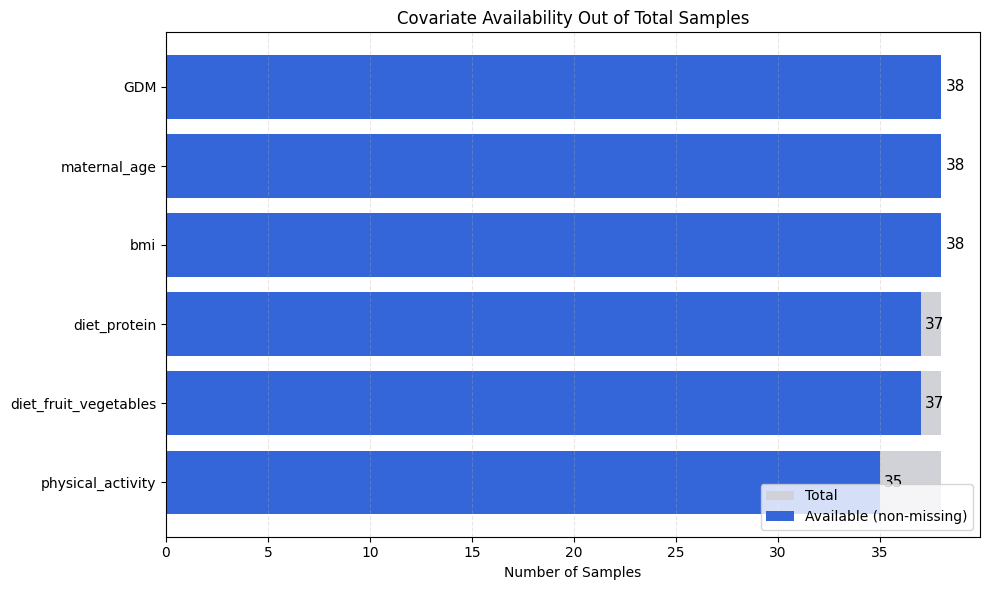

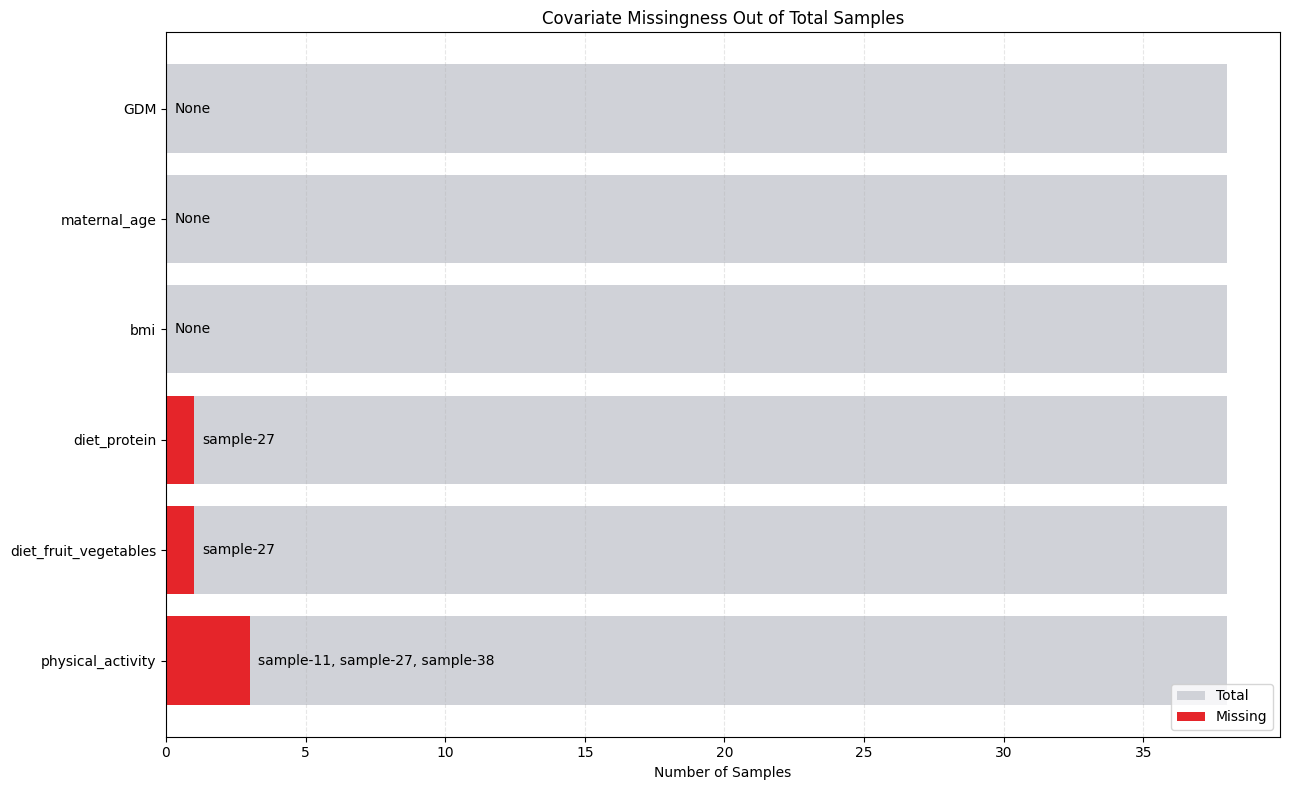

In [8]:
# Step 5 Visualization: Availability and missingness bars (like reference)
import matplotlib.pyplot as plt

# Counts per covariate
total_n = len(cov_matrix)
missing_counts = cov_matrix.isna().sum()
available_counts = total_n - missing_counts

# Sort to match the style in reference plots
plot_order = available_counts.sort_values(ascending=False).index.tolist()

# Build text labels listing which samples are missing per covariate
missing_sample_labels = {}
for col in plot_order:
    missing_samples = cov_matrix.index[cov_matrix[col].isna()].tolist()
    missing_sample_labels[col] = ", ".join(missing_samples) if missing_samples else "None"

# 1) Availability out of total
fig, ax = plt.subplots(figsize=(10, 6))
ypos = range(len(plot_order))
ax.barh(ypos, [total_n] * len(plot_order), color="#d0d2d8", label="Total")
ax.barh(ypos, [available_counts[c] for c in plot_order], color="#3465d9", label="Available (non-missing)")

ax.set_yticks(list(ypos))
ax.set_yticklabels(plot_order)
ax.invert_yaxis()
ax.set_xlabel("Number of Samples")
ax.set_title("Covariate Availability Out of Total Samples")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(loc="lower right")

for i, c in enumerate(plot_order):
    ax.text(available_counts[c] + 0.2, i, f"{int(available_counts[c])}", va="center", fontsize=11)

plt.tight_layout()
plt.show()

# 2) Missingness out of total + missing sample names
fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(ypos, [total_n] * len(plot_order), color="#d0d2d8", label="Total")
ax.barh(ypos, [missing_counts[c] for c in plot_order], color="#e5252a", label="Missing")

ax.set_yticks(list(ypos))
ax.set_yticklabels(plot_order)
ax.invert_yaxis()
ax.set_xlabel("Number of Samples")
ax.set_title("Covariate Missingness Out of Total Samples")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(loc="lower right")

for i, c in enumerate(plot_order):
    ax.text(missing_counts[c] + 0.3, i, missing_sample_labels[c], va="center", fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
cov_matrix.head(38)

,GDM,maternal_age,bmi,diet_protein,diet_fruit_vegetables,physical_activity
Sample,,,,,,
sample-1,0,34,28.040378,4.50,4.50,1
sample-2,1,28,25.217359,3.25,4.50,1
sample-3,0,28,24.242424,12.50,12.50,1
sample-4,1,37,22.375680,8.50,24.00,0
sample-5,0,32,20.195578,30.00,30.00,1
sample-6,1,33,21.875000,14.65,21.00,0
sample-7,0,32,21.303949,14.65,21.00,0
sample-8,0,32,24.034610,20.25,30.00,0
sample-9,1,37,22.206331,15.00,27.00,0


In [71]:
# Mean of Maternal Age from cov_matrix
if 'maternal_age' not in cov_matrix.columns:
    raise KeyError("'maternal_age' column not found in cov_matrix")

maternal_age_mean = pd.to_numeric(cov_matrix['maternal_age'], errors='coerce').mean()
print(f"Mean Maternal Age: {maternal_age_mean:.4f}")

Mean Maternal Age: 32.0789


In [72]:
# Standard deviation of Maternal Age from cov_matrix
if 'maternal_age' not in cov_matrix.columns:
    raise KeyError("'maternal_age' column not found in cov_matrix")

maternal_age_std = pd.to_numeric(cov_matrix['maternal_age'], errors='coerce').std()
print(f"Standard Deviation of Maternal Age: {maternal_age_std:.4f}")

Standard Deviation of Maternal Age: 3.5442


In [74]:
# Maternal Age summary table for Non-GDM, GDM, and All samples
maternal_age_series = pd.to_numeric(cov_matrix['maternal_age'], errors='coerce')
gdm_series = cov_matrix['GDM'].astype(str)

summary_rows = []
for group_name, group_values in [
    ('Non-GDM', maternal_age_series[gdm_series.isin(['0', '0.0'])]),
    ('GDM', maternal_age_series[gdm_series.isin(['1', '1.0'])]),
    ('All', maternal_age_series),
]:
    summary_rows.append({
        'Group': group_name,
        'Total': int(group_values.notna().sum()),
        'Mean_Maternal_Age': group_values.mean(),
        'SD_Maternal_Age': group_values.std(),
    })

maternal_age_summary = pd.DataFrame(summary_rows)
print('Maternal Age Summary Table:')
display(maternal_age_summary)

Maternal Age Summary Table:


,Group,Total,Mean_Maternal_Age,SD_Maternal_Age
0,Non-GDM,22,31.000000,2.894987
1,GDM,16,33.562500,3.898183
2,All,38,32.078947,3.544174


In [75]:
# BMI summary table for Non-GDM, GDM, and All samples
bmi_series = pd.to_numeric(cov_matrix['bmi'], errors='coerce')
gdm_series = cov_matrix['GDM'].astype(str)

bmi_rows = []
for group_name, group_values in [
    ('Non-GDM', bmi_series[gdm_series.isin(['0', '0.0'])]),
    ('GDM', bmi_series[gdm_series.isin(['1', '1.0'])]),
    ('All', bmi_series),
]:
    bmi_rows.append({
        'Group': group_name,
        'Total': int(group_values.notna().sum()),
        'Mean_BMI': group_values.mean(),
        'SD_BMI': group_values.std(),
    })

bmi_summary = pd.DataFrame(bmi_rows)
print('BMI Summary Table:')
display(bmi_summary)

BMI Summary Table:


,Group,Total,Mean_BMI,SD_BMI
0,Non-GDM,22,23.331892,3.568163
1,GDM,16,23.045307,3.107035
2,All,38,23.211224,3.340713


In [76]:
# Protein frequency summary table for Non-GDM, GDM, and All samples
protein_series = pd.to_numeric(cov_matrix['diet_protein'], errors='coerce')
gdm_series = cov_matrix['GDM'].astype(str)

protein_rows = []
for group_name, group_values in [
    ('Non-GDM', protein_series[gdm_series.isin(['0', '0.0'])]),
    ('GDM', protein_series[gdm_series.isin(['1', '1.0'])]),
    ('All', protein_series),
]:
    protein_rows.append({
        'Group': group_name,
        'Total': int(group_values.notna().sum()),
        'Sum_Protein_Frequency': group_values.sum(),
        'Mean_Protein_Frequency': group_values.mean(),
        'SD_Protein_Frequency': group_values.std(),
    })

protein_summary = pd.DataFrame(protein_rows)
print('Protein Frequency Summary Table:')
display(protein_summary)

Protein Frequency Summary Table:


,Group,Total,Sum_Protein_Frequency,Mean_Protein_Frequency,SD_Protein_Frequency
0,Non-GDM,22,352.200000,16.009091,6.618078
1,GDM,16,249.997297,15.624831,6.091873
2,All,38,602.197297,15.847297,6.319874


In [77]:
# Vegetables and fruits frequency summary table for Non-GDM, GDM, and All samples
vegfruit_series = pd.to_numeric(cov_matrix['diet_fruit_vegetables'], errors='coerce')
gdm_series = cov_matrix['GDM'].astype(str)

vegfruit_rows = []
for group_name, group_values in [
    ('Non-GDM', vegfruit_series[gdm_series.isin(['0', '0.0'])]),
    ('GDM', vegfruit_series[gdm_series.isin(['1', '1.0'])]),
    ('All', vegfruit_series),
]:
    vegfruit_rows.append({
        'Group': group_name,
        'Total': int(group_values.notna().sum()),
        'Sum_VegFruits_Frequency': group_values.sum(),
        'Mean_VegFruits_Frequency': group_values.mean(),
        'SD_VegFruits_Frequency': group_values.std(),
    })

vegfruit_summary = pd.DataFrame(vegfruit_rows)
print('Vegetables and Fruits Frequency Summary Table:')
display(vegfruit_summary)

Vegetables and Fruits Frequency Summary Table:


,Group,Total,Sum_VegFruits_Frequency,Mean_VegFruits_Frequency,SD_VegFruits_Frequency
0,Non-GDM,22,442.250000,20.102273,6.781742
1,GDM,16,302.395946,18.899747,7.173722
2,All,38,744.645946,19.595946,6.879586


In [78]:
# Physical Activity in last 3 months summary table (n(%)) for Non-GDM, GDM, and All samples
pa_series = pd.to_numeric(cov_matrix['physical_activity'], errors='coerce')
gdm_series = cov_matrix['GDM'].astype(str)

label_map = {
    0: 'No',
    1: 'Yes',
    0.0: 'No',
    1.0: 'Yes'
}

pa_summary_rows = []
for group_name, group_mask in [
    ('Non-GDM', gdm_series.isin(['0', '0.0'])),
    ('GDM', gdm_series.isin(['1', '1.0'])),
    ('All', pd.Series([True] * len(cov_matrix), index=cov_matrix.index)),
]:
    group_values = pa_series[group_mask].dropna()
    total = int(group_values.shape[0])
    yes_n = int((group_values == 1).sum())
    no_n = int((group_values == 0).sum())
    pa_summary_rows.append({
        'Group': group_name,
        'Yes_n(%)': f"{yes_n} ({(100 * yes_n / total):.1f}%)" if total else '0 (0.0%)',
        'No_n(%)': f"{no_n} ({(100 * no_n / total):.1f}%)" if total else '0 (0.0%)',
        'Total': total,
    })

pa_summary = pd.DataFrame(pa_summary_rows)
print('Physical Activity in Last 3 Months Summary Table:')
display(pa_summary)

Physical Activity in Last 3 Months Summary Table:


,Group,Yes_n(%),No_n(%),Total
0,Non-GDM,10 (45.5%),12 (54.5%),22
1,GDM,9 (56.2%),7 (43.8%),16
2,All,19 (50.0%),19 (50.0%),38


In [85]:
# Export one combined table with all summary values
combined_summary_rows = []

for _, row in maternal_age_summary.iterrows():
    combined_summary_rows.append({
        'Metric': 'Maternal Age',
        'Group': row['Group'],
        'Total': int(row['Total']),
        'Mean': row['Mean_Maternal_Age'],
        'SD': row['SD_Maternal_Age'],
        'Sum': pd.NA,
        'Yes_n(%)': pd.NA,
        'No_n(%)': pd.NA,
    })

for _, row in bmi_summary.iterrows():
    combined_summary_rows.append({
        'Metric': 'BMI',
        'Group': row['Group'],
        'Total': int(row['Total']),
        'Mean': row['Mean_BMI'],
        'SD': row['SD_BMI'],
        'Sum': pd.NA,
        'Yes_n(%)': pd.NA,
        'No_n(%)': pd.NA,
    })

for _, row in protein_summary.iterrows():
    combined_summary_rows.append({
        'Metric': 'Protein frequency (times/week)',
        'Group': row['Group'],
        'Total': int(row['Total']),
        'Mean': row['Mean_Protein_Frequency'],
        'SD': row['SD_Protein_Frequency'],
        'Sum': row['Sum_Protein_Frequency'],
        'Yes_n(%)': pd.NA,
        'No_n(%)': pd.NA,
    })

for _, row in vegfruit_summary.iterrows():
    combined_summary_rows.append({
        'Metric': 'Vegetables and fruits frequency (times/week)',
        'Group': row['Group'],
        'Total': int(row['Total']),
        'Mean': row['Mean_VegFruits_Frequency'],
        'SD': row['SD_VegFruits_Frequency'],
        'Sum': row['Sum_VegFruits_Frequency'],
        'Yes_n(%)': pd.NA,
        'No_n(%)': pd.NA,
    })

for _, row in pa_summary.iterrows():
    combined_summary_rows.append({
        'Metric': 'Physical Activity in last 3 months',
        'Group': row['Group'],
        'Total': int(row['Total']),
        'Mean': pd.NA,
        'SD': pd.NA,
        'Sum': pd.NA,
        'Yes_n(%)': row['Yes_n(%)'],
        'No_n(%)': row['No_n(%)'],
    })

combined_summary = pd.DataFrame(combined_summary_rows)
combined_summary = combined_summary[['Metric', 'Group', 'Total', 'Sum', 'Mean', 'SD', 'Yes_n(%)', 'No_n(%)']]

combined_summary_path = os.path.join(OUTPUTS_DIR, 'ml_modeling', 'Python_outputs', 'CSV_files', 'Table1_before_cleaning.csv')
os.makedirs(os.path.dirname(combined_summary_path), exist_ok=True)
combined_summary.to_csv(combined_summary_path, index=False)

print(f"Saved combined summary table to: {combined_summary_path}")
display(combined_summary)

Saved combined summary table to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/Python_outputs/CSV_files/Table1_before_cleaning.csv


,Metric,Group,Total,Sum,Mean,SD,Yes_n(%),No_n(%)
0,Maternal Age,Non-GDM,22,<NA>,31.0,2.894987,<NA>,<NA>
1,Maternal Age,GDM,16,<NA>,33.5625,3.898183,<NA>,<NA>
2,Maternal Age,All,38,<NA>,32.078947,3.544174,<NA>,<NA>
3,BMI,Non-GDM,22,<NA>,23.331892,3.568163,<NA>,<NA>
4,BMI,GDM,16,<NA>,23.045307,3.107035,<NA>,<NA>
5,BMI,All,38,<NA>,23.211224,3.340713,<NA>,<NA>
6,Protein frequency (times/week),Non-GDM,22,352.2,16.009091,6.618078,<NA>,<NA>
7,Protein frequency (times/week),GDM,16,249.997297,15.624831,6.091873,<NA>,<NA>
8,Protein frequency (times/week),All,38,602.197297,15.847297,6.319874,<NA>,<NA>
9,Vegetables and fruits frequency (times/week),Non-GDM,22,442.25,20.102273,6.781742,<NA>,<NA>


# Repeat same for raw data

In [10]:
# Mean-impute the two diet covariates with missing values
impute_cols = ["diet_protein", "diet_fruit_vegetables"]

before_missing = cov_matrix[impute_cols].isna().sum()
impute_values = {}

for col in impute_cols:
    mean_val = cov_matrix[col].mean(skipna=True)
    impute_values[col] = mean_val
    cov_matrix[col] = cov_matrix[col].fillna(mean_val)

after_missing = cov_matrix[impute_cols].isna().sum()

print("Imputed values used:")
for col, value in impute_values.items():
    print(f"{col}: {value}")

print("\nMissing values before imputation:")
print(before_missing)
print("\nMissing values after imputation:")
print(after_missing)

Imputed values used:
diet_protein: 15.847297297297295
diet_fruit_vegetables: 19.595945945945946

Missing values before imputation:
diet_protein             1
diet_fruit_vegetables    1
dtype: int64

Missing values after imputation:
diet_protein             0
diet_fruit_vegetables    0
dtype: int64


In [11]:
# KNN imputation for the missing physical_activity values
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from IPython.display import display

target_col = "physical_activity"
knn_impute_df = cov_matrix.copy()

fallback_samples = ["sample-11", "sample-27", "sample-38"]

target_numeric = pd.to_numeric(knn_impute_df[target_col], errors="coerce")
feature_cols = [col for col in knn_impute_df.columns if col != target_col]
feature_matrix = knn_impute_df[feature_cols].apply(pd.to_numeric, errors="coerce")
feature_matrix = feature_matrix.fillna(feature_matrix.median(numeric_only=True)).fillna(0)

observed_mask = target_numeric.notna()
missing_mask = target_numeric.isna()
use_fallback = int(missing_mask.sum()) == 0

if use_fallback:
    missing_mask = knn_impute_df.index.isin(fallback_samples)
    observed_mask = ~missing_mask
    print("No missing physical_activity values found; reconstructing the KNN table for the previously imputed samples.")
else:
    print(f"Found {int(missing_mask.sum())} missing physical_activity value(s); imputing those rows.")

missing_mask_array = np.asarray(missing_mask)
observed_mask_array = np.asarray(observed_mask)
missing_index = knn_impute_df.index[missing_mask_array]
observed_index = knn_impute_df.index[observed_mask_array]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)

n_neighbors = min(5, int(observed_mask_array.sum()))
if n_neighbors == 0:
    raise RuntimeError("No observed samples available for KNN imputation.")

nn = NearestNeighbors(n_neighbors=n_neighbors, metric="euclidean")
nn.fit(scaled_features[observed_mask_array])
distances, neighbor_positions = nn.kneighbors(scaled_features[missing_mask_array])

imputation_rows = []
for sample_id, neighbor_pos, dist in zip(missing_index, neighbor_positions, distances):
    neighbor_samples = observed_index.to_numpy()[neighbor_pos]
    neighbor_labels = target_numeric.loc[neighbor_samples].astype(int).to_numpy()
    weights = 1 / (dist + 1e-8)
    weighted_vote = float(np.average(neighbor_labels, weights=weights))
    imputed_value = int(weighted_vote >= 0.5)

    if not use_fallback:
        knn_impute_df.loc[sample_id, target_col] = imputed_value

    imputation_rows.append({
        "sample_id": sample_id,
        "nearest_neighbors": ", ".join(neighbor_samples.tolist()),
        "neighbor_distances": [round(x, 4) for x in dist.tolist()],
        "neighbor_values": neighbor_labels.tolist(),
        "weighted_avg": round(weighted_vote, 4),
        "filled_value": imputed_value,
    })

if not use_fallback:
    cov_matrix[target_col] = pd.Categorical(
        pd.to_numeric(knn_impute_df[target_col], errors="coerce").astype("Int64"),
        categories=[0, 1],
    )

imputation_table = pd.DataFrame(imputation_rows)
print("KNN imputation summary:")
display(imputation_table)

print("\nMissing values after KNN imputation:")
if use_fallback:
    display(pd.DataFrame({"missing_count": [0]}, index=[target_col]))
else:
    display(cov_matrix[[target_col]].isna().sum().to_frame(name="missing_count"))

# Final cleaned covariate matrix name for downstream modeling
cov_clean = cov_matrix.copy()
print("\nCreated cleaned covariate matrix: cov_clean")

Found 3 missing physical_activity value(s); imputing those rows.
KNN imputation summary:


,sample_id,nearest_neighbors,neighbor_distances,neighbor_values,weighted_avg,filled_value
0,sample-11,"sample-31, sample-21, sample-17, sample-6, sam...","[1.0535, 1.4069, 1.4352, 1.906, 1.9586]","[0, 1, 1, 0, 0]",0.4150,0
1,sample-27,"sample-19, sample-6, sample-15, sample-21, sam...","[0.9103, 1.1834, 1.1847, 1.6721, 1.6959]","[1, 0, 0, 1, 1]",0.5751,1
2,sample-38,"sample-3, sample-12, sample-1, sample-22, samp...","[1.5274, 1.5598, 1.6756, 1.8563, 2.0379]","[1, 1, 1, 1, 0]",0.8321,1



Missing values after KNN imputation:


,missing_count
physical_activity,0



Created cleaned covariate matrix: cov_clean


In [84]:
# Combined summary table using cov_clean after imputation/fill values
combined_summary_cov_clean_rows = []

# Maternal Age
maternal_age_series_clean = pd.to_numeric(cov_clean['maternal_age'], errors='coerce')
gdm_series_clean = cov_clean['GDM'].astype(str)
for _, row in pd.DataFrame({
    'Group': ['Non-GDM', 'GDM', 'All'],
    'Values': [
        maternal_age_series_clean[gdm_series_clean.isin(['0', '0.0'])],
        maternal_age_series_clean[gdm_series_clean.isin(['1', '1.0'])],
        maternal_age_series_clean,
    ],
}).iterrows():
    values = row['Values']
    combined_summary_cov_clean_rows.append({
        'Metric': 'Maternal Age',
        'Group': row['Group'],
        'Total': int(values.notna().sum()),
        'Sum': pd.NA,
        'Mean': values.mean(),
        'SD': values.std(),
        'Yes_n(%)': pd.NA,
        'No_n(%)': pd.NA,
    })

# BMI
bmi_series_clean = pd.to_numeric(cov_clean['bmi'], errors='coerce')
for _, row in pd.DataFrame({
    'Group': ['Non-GDM', 'GDM', 'All'],
    'Values': [
        bmi_series_clean[gdm_series_clean.isin(['0', '0.0'])],
        bmi_series_clean[gdm_series_clean.isin(['1', '1.0'])],
        bmi_series_clean,
    ],
}).iterrows():
    values = row['Values']
    combined_summary_cov_clean_rows.append({
        'Metric': 'BMI',
        'Group': row['Group'],
        'Total': int(values.notna().sum()),
        'Sum': pd.NA,
        'Mean': values.mean(),
        'SD': values.std(),
        'Yes_n(%)': pd.NA,
        'No_n(%)': pd.NA,
    })

# Protein frequency
protein_series_clean = pd.to_numeric(cov_clean['diet_protein'], errors='coerce')
for _, row in pd.DataFrame({
    'Group': ['Non-GDM', 'GDM', 'All'],
    'Values': [
        protein_series_clean[gdm_series_clean.isin(['0', '0.0'])],
        protein_series_clean[gdm_series_clean.isin(['1', '1.0'])],
        protein_series_clean,
    ],
}).iterrows():
    values = row['Values']
    combined_summary_cov_clean_rows.append({
        'Metric': 'Protein frequency (times/week)',
        'Group': row['Group'],
        'Total': int(values.notna().sum()),
        'Sum': values.sum(),
        'Mean': values.mean(),
        'SD': values.std(),
        'Yes_n(%)': pd.NA,
        'No_n(%)': pd.NA,
    })

# Vegetables and fruits frequency
vegfruit_series_clean = pd.to_numeric(cov_clean['diet_fruit_vegetables'], errors='coerce')
for _, row in pd.DataFrame({
    'Group': ['Non-GDM', 'GDM', 'All'],
    'Values': [
        vegfruit_series_clean[gdm_series_clean.isin(['0', '0.0'])],
        vegfruit_series_clean[gdm_series_clean.isin(['1', '1.0'])],
        vegfruit_series_clean,
    ],
}).iterrows():
    values = row['Values']
    combined_summary_cov_clean_rows.append({
        'Metric': 'Vegetables and fruits frequency (times/week)',
        'Group': row['Group'],
        'Total': int(values.notna().sum()),
        'Sum': values.sum(),
        'Mean': values.mean(),
        'SD': values.std(),
        'Yes_n(%)': pd.NA,
        'No_n(%)': pd.NA,
    })

# Physical activity
pa_series_clean = pd.to_numeric(cov_clean['physical_activity'], errors='coerce')
for group_name, group_mask in [
    ('Non-GDM', gdm_series_clean.isin(['0', '0.0'])),
    ('GDM', gdm_series_clean.isin(['1', '1.0'])),
    ('All', pd.Series([True] * len(cov_clean), index=cov_clean.index)),
]:
    values = pa_series_clean[group_mask].dropna()
    total = int(values.shape[0])
    yes_n = int((values == 1).sum())
    no_n = int((values == 0).sum())
    combined_summary_cov_clean_rows.append({
        'Metric': 'Physical Activity in last 3 months',
        'Group': group_name,
        'Total': total,
        'Sum': pd.NA,
        'Mean': pd.NA,
        'SD': pd.NA,
        'Yes_n(%)': f"{yes_n} ({(100 * yes_n / total):.1f}%)" if total else '0 (0.0%)',
        'No_n(%)': f"{no_n} ({(100 * no_n / total):.1f}%)" if total else '0 (0.0%)',
    })

combined_summary_cov_clean = pd.DataFrame(combined_summary_cov_clean_rows)
combined_summary_cov_clean = combined_summary_cov_clean[[
    'Metric', 'Group', 'Total', 'Sum', 'Mean', 'SD', 'Yes_n(%)', 'No_n(%)'
]]

combined_summary_cov_clean_path = os.path.join(
    OUTPUTS_DIR,
    'ml_modeling',
    'Python_outputs',
    'CSV_files',
    'Table1_after_cleaning.csv'
)
os.makedirs(os.path.dirname(combined_summary_cov_clean_path), exist_ok=True)
combined_summary_cov_clean.to_csv(combined_summary_cov_clean_path, index=False)

print(f"Saved cov_clean combined summary table to: {combined_summary_cov_clean_path}")
display(combined_summary_cov_clean)

Saved cov_clean combined summary table to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/Python_outputs/CSV_files/Table1_after_cleaning.csv


,Metric,Group,Total,Sum,Mean,SD,Yes_n(%),No_n(%)
0,Maternal Age,Non-GDM,22,<NA>,31.0,2.894987,<NA>,<NA>
1,Maternal Age,GDM,16,<NA>,33.5625,3.898183,<NA>,<NA>
2,Maternal Age,All,38,<NA>,32.078947,3.544174,<NA>,<NA>
3,BMI,Non-GDM,22,<NA>,23.331892,3.568163,<NA>,<NA>
4,BMI,GDM,16,<NA>,23.045307,3.107035,<NA>,<NA>
5,BMI,All,38,<NA>,23.211224,3.340713,<NA>,<NA>
6,Protein frequency (times/week),Non-GDM,22,352.2,16.009091,6.618078,<NA>,<NA>
7,Protein frequency (times/week),GDM,16,249.997297,15.624831,6.091873,<NA>,<NA>
8,Protein frequency (times/week),All,38,602.197297,15.847297,6.319874,<NA>,<NA>
9,Vegetables and fruits frequency (times/week),Non-GDM,22,442.25,20.102273,6.781742,<NA>,<NA>


No missing physical_activity values found; showing the previously imputed samples as missing markers.


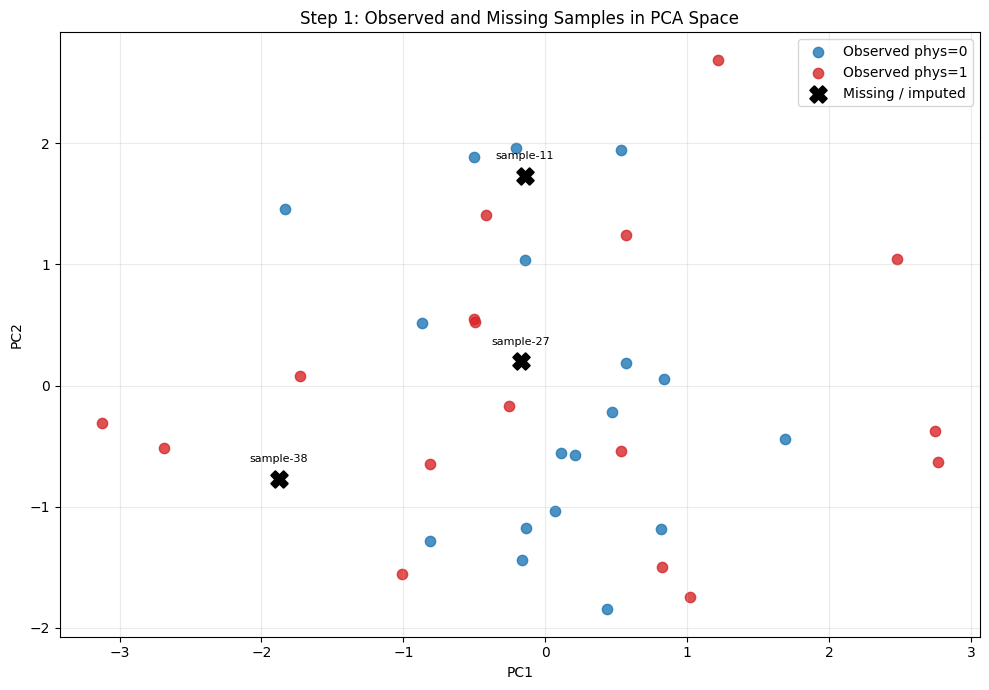

In [12]:
# Plot 1: Observed and missing samples only
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

fallback_samples = ["sample-11", "sample-27", "sample-38"]
target_col = "physical_activity"
plot_df = cov_matrix.copy()

target_numeric = pd.to_numeric(plot_df[target_col], errors="coerce")
feature_cols = [col for col in plot_df.columns if col != target_col]
feature_matrix = plot_df[feature_cols].apply(pd.to_numeric, errors="coerce")
feature_matrix = feature_matrix.fillna(feature_matrix.median(numeric_only=True)).fillna(0)

observed_mask = target_numeric.notna()
missing_mask = target_numeric.isna()
use_fallback = int(missing_mask.sum()) == 0

if use_fallback:
    missing_mask = plot_df.index.isin(fallback_samples)
    observed_mask = ~missing_mask
    print("No missing physical_activity values found; showing the previously imputed samples as missing markers.")
else:
    print(f"Found {int(missing_mask.sum())} missing physical_activity value(s); plotting them as missing markers.")

scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)
pca = PCA(n_components=2, random_state=42)
knn_X_2d = pca.fit_transform(scaled_features)

obs_mask = np.asarray(observed_mask)
miss_mask = np.asarray(missing_mask)
obs_idx = np.where(obs_mask)[0]
miss_idx = np.where(miss_mask)[0]
obs_labels = pd.to_numeric(plot_df.loc[observed_mask, target_col], errors='coerce')
zero_idx = np.where(obs_labels.to_numpy() == 0)[0]
one_idx = np.where(obs_labels.to_numpy() == 1)[0]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(knn_X_2d[obs_idx[zero_idx], 0], knn_X_2d[obs_idx[zero_idx], 1], c='#1f77b4', s=55, alpha=0.8, label='Observed phys=0')
ax.scatter(knn_X_2d[obs_idx[one_idx], 0], knn_X_2d[obs_idx[one_idx], 1], c='#d62728', s=55, alpha=0.8, label='Observed phys=1')
ax.scatter(knn_X_2d[miss_idx, 0], knn_X_2d[miss_idx, 1], c='black', marker='X', s=140, linewidths=1.5, label='Missing / imputed')

for sample, miss_pos in zip(plot_df.index[miss_mask], miss_idx):
    ax.annotate(
        sample,
        (knn_X_2d[miss_pos, 0], knn_X_2d[miss_pos, 1]),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=8,
    )

ax.set_title('Step 1: Observed and Missing Samples in PCA Space')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(loc='best')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

No missing physical_activity values found; reconstructing the neighbor map for the previously imputed samples.


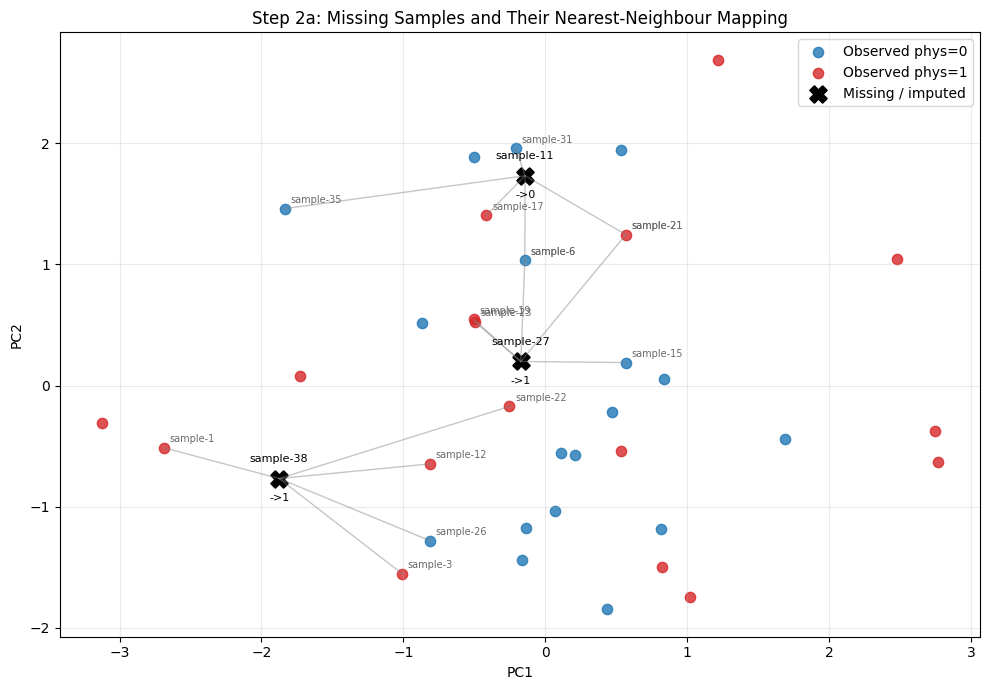

In [13]:
# Plot 1.5: Map which observed points are selected as nearest neighbors for each missing sample
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

fallback_samples = ["sample-11", "sample-27", "sample-38"]
target_col = "physical_activity"
plot_df = cov_matrix.copy()

target_numeric = pd.to_numeric(plot_df[target_col], errors="coerce")
feature_cols = [col for col in plot_df.columns if col != target_col]
feature_matrix = plot_df[feature_cols].apply(pd.to_numeric, errors="coerce")
feature_matrix = feature_matrix.fillna(feature_matrix.median(numeric_only=True)).fillna(0)

observed_mask = target_numeric.notna()
missing_mask = target_numeric.isna()
use_fallback = int(missing_mask.sum()) == 0

if use_fallback:
    missing_mask = plot_df.index.isin(fallback_samples)
    observed_mask = ~missing_mask
    print("No missing physical_activity values found; reconstructing the neighbor map for the previously imputed samples.")
else:
    print(f"Found {int(missing_mask.sum())} missing physical_activity value(s); plotting their nearest neighbors.")

scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)
pca = PCA(n_components=2, random_state=42)
knn_X_2d = pca.fit_transform(scaled_features)

obs_mask = np.asarray(observed_mask)
miss_mask = np.asarray(missing_mask)
obs_idx = np.where(obs_mask)[0]
miss_idx = np.where(miss_mask)[0]
obs_labels = pd.to_numeric(plot_df.loc[observed_mask, target_col], errors='coerce')
zero_idx = np.where(obs_labels.to_numpy() == 0)[0]
one_idx = np.where(obs_labels.to_numpy() == 1)[0]
observed_index = plot_df.index[observed_mask]
missing_index = plot_df.index[missing_mask]

n_neighbors = min(5, int(obs_mask.sum()))
if n_neighbors == 0:
    raise RuntimeError('No observed samples available for KNN imputation.')

nn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
nn.fit(scaled_features[obs_mask])
distances, neighbor_positions = nn.kneighbors(scaled_features[miss_mask])

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(knn_X_2d[obs_idx[zero_idx], 0], knn_X_2d[obs_idx[zero_idx], 1], c='#1f77b4', s=55, alpha=0.8, label='Observed phys=0')
ax.scatter(knn_X_2d[obs_idx[one_idx], 0], knn_X_2d[obs_idx[one_idx], 1], c='#d62728', s=55, alpha=0.8, label='Observed phys=1')
ax.scatter(knn_X_2d[miss_idx, 0], knn_X_2d[miss_idx, 1], c='black', marker='X', s=140, linewidths=1.5, label='Missing / imputed')

for i, sample in enumerate(missing_index):
    miss_pos = miss_idx[i]
    nbr_rel_positions = neighbor_positions[i]
    nbr_abs_positions = obs_idx[nbr_rel_positions]
    nbr_samples = observed_index[nbr_rel_positions].tolist()
    nbr_values = obs_labels.iloc[nbr_rel_positions].to_numpy()
    nbr_dist = distances[i]

    weights = 1.0 / np.maximum(nbr_dist, 1e-9)
    weighted_score = float(np.sum(weights * nbr_values) / np.sum(weights))
    assigned_value = int(round(weighted_score))

    ax.annotate(
        sample,
        (knn_X_2d[miss_pos, 0], knn_X_2d[miss_pos, 1]),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=8,
    )

    for nbr_pos, nbr_name in zip(nbr_abs_positions, nbr_samples):
        ax.plot(
            [knn_X_2d[miss_pos, 0], knn_X_2d[nbr_pos, 0]],
            [knn_X_2d[miss_pos, 1], knn_X_2d[nbr_pos, 1]],
            color='gray', alpha=0.45, linewidth=1
        )
        ax.annotate(
            nbr_name,
            (knn_X_2d[nbr_pos, 0], knn_X_2d[nbr_pos, 1]),
            textcoords='offset points',
            xytext=(4, 4),
            fontsize=7,
            color='dimgray',
        )

    ax.annotate(
        f'->{assigned_value}',
        (knn_X_2d[miss_pos, 0], knn_X_2d[miss_pos, 1]),
        textcoords='offset points',
        xytext=(0, -16),
        ha='center',
        fontsize=8,
        color='black',
    )

ax.set_title('Step 2a: Missing Samples and Their Nearest-Neighbour Mapping')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(loc='best')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [14]:
cov_clean.head(38)

,GDM,maternal_age,bmi,diet_protein,diet_fruit_vegetables,physical_activity
Sample,,,,,,
sample-1,0,34,28.040378,4.500000,4.500000,1
sample-2,1,28,25.217359,3.250000,4.500000,1
sample-3,0,28,24.242424,12.500000,12.500000,1
sample-4,1,37,22.375680,8.500000,24.000000,0
sample-5,0,32,20.195578,30.000000,30.000000,1
sample-6,1,33,21.875000,14.650000,21.000000,0
sample-7,0,32,21.303949,14.650000,21.000000,0
sample-8,0,32,24.034610,20.250000,30.000000,0
sample-9,1,37,22.206331,15.000000,27.000000,0


In [15]:
# Filter cord data to match available covariate samples
cord_clean = cord_matrix.loc[cov_clean.index]
print(f"\nCord data shape after matching: {cord_clean.shape}")


Cord data shape after matching: (38, 981)


In [16]:
# Check dtypes after cleaning
print("\nData types in cleaned covariate matrix:")
print(cov_clean.dtypes)
print("\nFactor covariates levels:")
print("GDM:", cov_clean['GDM'].cat.categories.tolist())
print("physical_activity:", cov_clean['physical_activity'].cat.categories.tolist())


Data types in cleaned covariate matrix:
GDM                      category
maternal_age                int64
bmi                       float64
diet_protein              float64
diet_fruit_vegetables     float64
physical_activity        category
dtype: object

Factor covariates levels:
GDM: [0, 1]
physical_activity: [0, 1]


In [17]:
## Demonstration: Steps 6-13 on First Metabolite

#We'll work through each calculation step-by-step on the first metabolite to understand each term, then apply to all metabolites.


In [18]:
cord_clean.head(38)

,107004,108005,109011,1101001,1101006,1102005,1102011,1102012,1102017,1102018,...,675024,675025,675026,675027,675028,675029,676007,677004,677011,634009
Sample,,,,,,,,,,,,,,,,,,,,,
sample-1,0.982920,0.997001,1.001218,1.001201,1.040406,1.000000,0.979128,0.897300,1.049986,0.918842,...,0.998943,0.995692,0.993673,1.006100,0.989948,0.995593,0.990328,0.977754,0.985770,0.976144
sample-2,0.991572,1.024139,1.014588,1.019298,0.853199,0.881035,1.010385,0.931008,1.059620,0.908615,...,1.001057,0.996019,1.003748,0.992310,1.000658,0.994897,1.012718,1.005144,1.000231,1.017369
sample-3,0.962144,0.972625,0.999607,0.891771,0.953293,1.001158,0.869336,0.897300,0.834241,0.908615,...,0.988019,0.990972,0.980308,0.982788,0.994468,0.983981,1.004100,0.979684,0.980854,0.961003
sample-4,1.005908,1.015966,1.000671,0.891771,0.853199,1.022224,0.869336,0.897300,0.943810,0.908615,...,0.983763,0.985011,0.993704,0.997537,0.998984,0.989069,1.023485,0.991362,0.981521,0.983039
sample-5,0.888982,0.989501,0.995799,1.092085,0.925969,1.022152,0.869336,0.897300,0.915130,0.908615,...,1.013374,1.007367,0.996035,0.987062,0.997701,1.008544,0.935841,0.986891,0.995214,0.979196
sample-6,0.936415,0.966933,1.001511,1.085668,0.927951,0.932325,0.869336,0.897300,0.908219,0.908615,...,0.997477,0.999022,0.995918,1.002968,1.000558,1.007961,0.952366,0.994578,0.996525,1.022623
sample-7,0.926607,1.009271,1.002519,0.891771,0.932275,1.016664,0.951294,0.897300,0.948767,0.908615,...,0.997615,1.007898,1.006565,1.008951,1.002414,1.011545,0.982356,1.021793,1.007157,1.003329
sample-8,1.009554,0.958469,0.993411,0.891771,0.862778,1.135285,0.869336,0.897300,0.900094,0.908615,...,0.981457,0.974797,0.973705,0.970117,0.987070,0.978230,0.941691,0.977910,0.972407,0.981213
sample-9,0.979675,0.952346,0.989498,0.891771,1.050900,1.161139,1.054652,1.000000,1.154361,1.148013,...,1.011428,1.010358,1.015158,1.008852,1.010948,1.019142,1.005846,1.012244,1.005407,0.997826


## Steps 6-13: Main Loop - Fit Models and Extract Statistics

For each metabolite i:
1. Extract metabolite column i
2. Fit: `lm(metabolite[i] ~ GDM + covariates)`
3. Extract p-value for GDM coefficient
4. Calculate mean for GDM=1 group
5. Calculate mean for GDM=0 group
6. Calculate log fold change
7. Convert to raw fold change (2^log_fc)
8. Store all values in vectors

**Stored vectors:**
- p_store: p-values for GDM
- m_GDM_store: means for GDM=1
- m_non_GDM_store: means for GDM=0
- log_fc_store: log fold changes
- raw_fc_store: raw fold changes

In [19]:
# Steps 6-13: Main loop across all metabolites
metabolite_annotations = list(cord_clean.columns)

p_store = []
m_GDM_store = []
m_non_GDM_store = []
log_fc_store = []
raw_fc_store = []

print(f"Starting loop over {len(metabolite_annotations)} metabolites...")
print("This will apply Steps 6-13 to each metabolite.\n")

for i, metabolite_name in enumerate(metabolite_annotations, start=1):
    # 1) Extract metabolite i and combine with covariates
    model_data = pd.concat([cord_clean[metabolite_name].rename("metabolite"), cov_clean], axis=1).dropna()

    if model_data.empty or model_data["GDM"].nunique() < 2:
        p_store.append(np.nan)
        m_GDM_store.append(np.nan)
        m_non_GDM_store.append(np.nan)
        log_fc_store.append(np.nan)
        raw_fc_store.append(np.nan)
    else:
        # 2) Fit lm(metabolite[i] ~ GDM + covariates)
        formula = 'metabolite ~ GDM + ' + ' + '.join([col for col in cov_clean.columns if col != 'GDM'])
        fit = sm.formula.ols(formula, data=model_data).fit()

        # 3) Extract p-value for GDM
        gdm_pval = fit.pvalues['GDM[T.1]'] if 'GDM[T.1]' in fit.pvalues.index else fit.pvalues.get('GDM', np.nan)

        # 4-5) Means by group
        m_gdm = model_data.loc[model_data["GDM"] == 1, "metabolite"].mean()
        m_non_gdm = model_data.loc[model_data["GDM"] == 0, "metabolite"].mean()

        # 6) Log fold change
        log_fc = m_gdm - m_non_gdm if pd.notna(m_gdm) and pd.notna(m_non_gdm) else np.nan

        # 7) Convert to raw fold change (2^log_fc)
        raw_fc = 2 ** log_fc if pd.notna(log_fc) else np.nan

        # 8) Store values in vectors
        p_store.append(gdm_pval)
        m_GDM_store.append(m_gdm)
        m_non_GDM_store.append(m_non_gdm)
        log_fc_store.append(log_fc)
        raw_fc_store.append(raw_fc)

    if i % 100 == 0:
        print(f"  Processed {i} metabolites...")

print(f"\n✓ Completed loop. Processed {len(metabolite_annotations)} metabolites.")
print(f"  p-values stored: {len(p_store)}")
print(f"  GDM means stored: {len(m_GDM_store)}")
print(f"  Non-GDM means stored: {len(m_non_GDM_store)}")
print(f"  Fold changes stored: {len(raw_fc_store)}")

Starting loop over 981 metabolites...
This will apply Steps 6-13 to each metabolite.

  Processed 100 metabolites...
  Processed 200 metabolites...
  Processed 300 metabolites...
  Processed 400 metabolites...
  Processed 500 metabolites...
  Processed 600 metabolites...
  Processed 700 metabolites...
  Processed 800 metabolites...
  Processed 900 metabolites...

✓ Completed loop. Processed 981 metabolites.
  p-values stored: 981
  GDM means stored: 981
  Non-GDM means stored: 981
  Fold changes stored: 981


## Step 14: Exit Loop and Prepare for Multiple Testing Correction

Convert stored vectors to arrays for further processing:
- p_store: raw p-values
- m_GDM_store: mean metabolite levels in GDM=1 group
- m_non_GDM_store: mean metabolite levels in GDM=0 group
- fc_store: fold changes
- log_fc_store: log fold changes
- raw_fc_store: raw fold changes

## Why this is important:

- The loop collects values as Python lists because appending is easy while iterating.
- Downstream stats functions (BH correction, q-values, result table creation) are cleaner and faster with arrays.
- It acts as a quality check:
- If lengths are unequal, something broke in the loop.
- If p-value summary looks odd (all nan, all 0, all 1), you catch issues before Step 15.


In [20]:
# Step 14: Convert to arrays for further processing
p_array = np.array(p_store)
m_gdm_array = np.array(m_GDM_store)
m_non_gdm_array = np.array(m_non_GDM_store)
log_fc_array = np.array(log_fc_store)
raw_fc_array = np.array(raw_fc_store)

print("Results vectors prepared:")
print(f"  p-values: {len(p_array)}")
print(f"  GDM means: {len(m_gdm_array)}")
print(f"  Non-GDM means: {len(m_non_gdm_array)}")
print(f"  Log fold changes: {len(log_fc_array)}")
print(f"  Raw fold changes: {len(raw_fc_array)}")

print(f"\nP-value summary:")
print(f"  Min: {np.nanmin(p_array)}")
print(f"  Max: {np.nanmax(p_array)}")
print(f"  Mean: {np.nanmean(p_array)}")
print(f"  Median: {np.nanmedian(p_array)}")

Results vectors prepared:
  p-values: 981
  GDM means: 981
  Non-GDM means: 981
  Log fold changes: 981
  Raw fold changes: 981

P-value summary:
  Min: 0.0008356608835822124
  Max: 0.9995609703263508
  Mean: 0.4974787971222118
  Median: 0.4944810622636434


## Step 15: Calculate Adjusted P-values Using Benjamini-Hochberg

Apply Benjamini-Hochberg (FDR) correction to the p-value vector to control false discovery rate across all metabolite tests.

In [21]:
from statsmodels.stats.multitest import multipletests

# Step 15: Calculate adjusted p-values using Benjamini-Hochberg
# multipletests returns: (reject, pvals_corrected, alphacSidak, alphacBonf)
reject_bh, pvals_adj_bh, _, _ = multipletests(p_array, method='fdr_bh')

print("Benjamini-Hochberg Correction Results:")
print(f"  Number of significant metabolites (FDR < 0.05): {reject_bh.sum()}")
print(f"  Min adjusted p-value: {np.nanmin(pvals_adj_bh)}")
print(f"  Max adjusted p-value: {np.nanmax(pvals_adj_bh)}")
print(f"  Mean adjusted p-value: {np.nanmean(pvals_adj_bh)}")
print(f"  Median adjusted p-value: {np.nanmedian(pvals_adj_bh)}")

Benjamini-Hochberg Correction Results:
  Number of significant metabolites (FDR < 0.05): 0
  Min adjusted p-value: 0.8197833267941503
  Max adjusted p-value: 0.9995609703263508
  Mean adjusted p-value: 0.967155979475896
  Median adjusted p-value: 0.9807307509714877


## Step 16: Calculate Q-values

Q-values provide another measure of statistical significance considering the proportion of false discoveries.
This uses the qvalue method (Storey's approach) to estimate the FDR at each p-value threshold.

In [22]:
# Step 16: Calculate q-values
try:
    from qvalue import qvalue
    q_vals = qvalue(p_array)['qvalues']
    print("Q-values calculated using qvalue package")
except ImportError:
    print("qvalue package not available, using Benjamini-Hochberg adjusted p-values as approximation")
    q_vals = pvals_adj_bh

print(f"\nQ-value Summary:")
print(f"  Min: {np.nanmin(q_vals)}")
print(f"  Max: {np.nanmax(q_vals)}")
print(f"  Mean: {np.nanmean(q_vals)}")
print(f"  Median: {np.nanmedian(q_vals)}")

qvalue package not available, using Benjamini-Hochberg adjusted p-values as approximation

Q-value Summary:
  Min: 0.8197833267941503
  Max: 0.9995609703263508
  Mean: 0.967155979475896
  Median: 0.9807307509714877


## Step 17: Create Results Table

Combine all results into a comprehensive table containing:
1. **Metabolite Annotation** - metabolite names/IDs
2. **p-value (raw)** - unadjusted p-values from linear models
3. **p-value (corrected)** - Benjamini-Hochberg adjusted p-values
4. **q-value** - Storey's q-values
5. **Mean GDM** - mean metabolite level in GDM positive women
6. **Mean Non-GDM** - mean metabolite level in non-GDM women
7. **Log Fold Change** - log-scale difference between groups
8. **Raw Fold Change** - back-transformed fold change (2^log_fc)

In [23]:
# Step 17: Create comprehensive results table

# Use metabolite_names if available; otherwise use metabolite_annotations from the main loop
if 'metabolite_names' in globals():
    metabolite_names_local = metabolite_names
else:
    metabolite_names_local = metabolite_annotations

# Get metabolite annotations if available
if CORD_ANNO is not None:
    anno_df = pd.read_csv(CORD_ANNO, index_col=0)
else:
    anno_df = None

# Create results dataframe
results_df = pd.DataFrame({
    'Metabolite': metabolite_names_local,
    'p_value_raw': p_array,
    'p_value_corrected': pvals_adj_bh,
    'q_value': q_vals,
    'Mean_GDM': m_gdm_array,
    'Mean_Non_GDM': m_non_gdm_array,
    'Log_Fold_Change': log_fc_array,
    'Raw_Fold_Change': raw_fc_array
})

# Add metabolite annotation if available
if anno_df is not None:
    # Map metabolite names to annotations
    anno_mapping = anno_df.to_dict('index')

    # Add annotation columns
    annotation_cols = []
    for met in metabolite_names_local:
        if met in anno_mapping:
            annotation_cols.append(anno_mapping[met])
        else:
            annotation_cols.append({col: None for col in anno_df.columns})

    anno_expanded = pd.DataFrame(annotation_cols)
    results_df = pd.concat([results_df, anno_expanded], axis=1)

# Sort by p-value (most significant first)
results_df = results_df.sort_values('p_value_raw')

print("Results Table Summary:")
print(f"  Total metabolites: {len(results_df)}")
print(f"\nFirst 10 rows (sorted by p-value):")
results_df.head(10)

Results Table Summary:
  Total metabolites: 981

First 10 rows (sorted by p-value):


,Metabolite,p_value_raw,p_value_corrected,q_value,Mean_GDM,Mean_Non_GDM,Log_Fold_Change,Raw_Fold_Change,COMPOUND Name,SUPER META PATHWAY,SUB META PATHWAY,ACQUISITION METHOD,HMDB ID,HMDB_annotation,PUBCHEM ID,CAS ID,KEGG ID,CHEMSPIDER ID
216,612027,0.000836,0.819783,0.819783,1.008620,0.994966,0.013654,1.009509,palmitoyl ethanolamide,Lipid,Endocannabinoid,NEGa,HMDB0002100,NaN,4671.0,544-31-0,C16512,4509.0
266,624012,0.003435,0.951433,0.951433,1.020930,0.992067,0.028863,1.020208,2-hydroxynervonate*,Lipid,"Fatty Acid, Monohydroxy",NEGa,NaN,NaN,NaN,NaN,NaN,NaN
432,801073,0.005975,0.951433,0.951433,0.931727,0.959118,-0.027391,0.981193,glycine conjugate of C10H12O2*,Partially Characterized Molecules,Partially Characterized Molecules,NEGa,NaN,NaN,NaN,NaN,NaN,NaN
43,111007,0.007513,0.951433,0.951433,1.027495,0.973024,0.054472,1.038479,3-methylhistidine,Amino Acid,Histidine Metabolism,NEGa,HMDB0000479,NaN,64969.0,368-16-1,C01152,58494.0
960,675013,0.008627,0.951433,0.951433,1.007696,0.995782,0.011914,1.008292,"sphingomyelin (d18:1/20:1, d18:2/20:0)*",Lipid,Sphingomyelins,POSb,HMDB0240610,"HMDB0240610,HMDB0240632(SM(d18:2(4E,14Z)/20:0))",52931179.0,222403-67-0,NaN,58164052.0
804,313007,0.011026,0.951433,0.951433,1.015011,0.975541,0.039470,1.027736,retinol (Vitamin A),Cofactors and Vitamins,Vitamin A Metabolism,POSb,HMDB0000305,NaN,445354.0,68-26-8,C17276,NaN
837,616011,0.011318,0.951433,0.951433,0.973940,1.024012,-0.050072,0.965888,4-methylnonanoylcarnitine,Lipid,"Fatty Acid Metabolism (Acyl Carnitine, Medium ...",POSb,NaN,NaN,NaN,NaN,NaN,NaN
975,675028,0.011712,0.951433,0.951433,1.005735,0.997281,0.008453,1.005876,stearoyl sphingomyelin (d18:1/18:0),Lipid,Sphingomyelins,POSb,HMDB0001348,NaN,6453725.0,58909-84-5,NaN,4956085.0
980,634009,0.011802,0.951433,0.951433,1.007102,0.991731,0.015371,1.010711,glycosyl-N-nervonoyl-sphingosine (d18:1/24:1)*,Lipid,Hexosylceramides (HCER),POSb,HMDB0004975,"HMDB0004975,HMDB0010712(Galactosylceramide (d1...",20057357.0,NaN,C01190,16744960.0
260,624003,0.012351,0.951433,0.951433,1.022047,0.981890,0.040157,1.028225,14-HDoHE/17-HDoHE,Lipid,Docosanoid,NEGa,HMDB0060044,"HMDB0060044,HMDB0010213(17-HDoHE)",131769804.0,NaN,NaN,NaN


In [24]:
# Save Step 17 results to CSV
save_path = os.path.join(OUTPUTS_DIR, "ml_modeling", "output_csv", "08_cord_gdm", "Linear_Model_data.csv")
os.makedirs(os.path.dirname(save_path), exist_ok=True)

results_df.to_csv(save_path, index=False)
print(f"Saved results to: {save_path}")
print(f"Rows: {len(results_df)}, Columns: {results_df.shape[1]}")

Saved results to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/output_csv/08_cord_gdm/Linear_Model_data.csv
Rows: 981, Columns: 18


## Visualization Suite (Plots)

These plots summarize significance, effect size, and GDM vs non-GDM patterns from the model outputs.


## Final Conclusion Plot: Significant Difference (GDM Yes/No)

This plot gives a direct answer to the research question using FDR-adjusted significance.


## Companion Plot: Raw p-value vs FDR Thresholds

This plot compares significance counts under two thresholds:
- Raw `p < 0.05`
- Adjusted `FDR < 0.05`


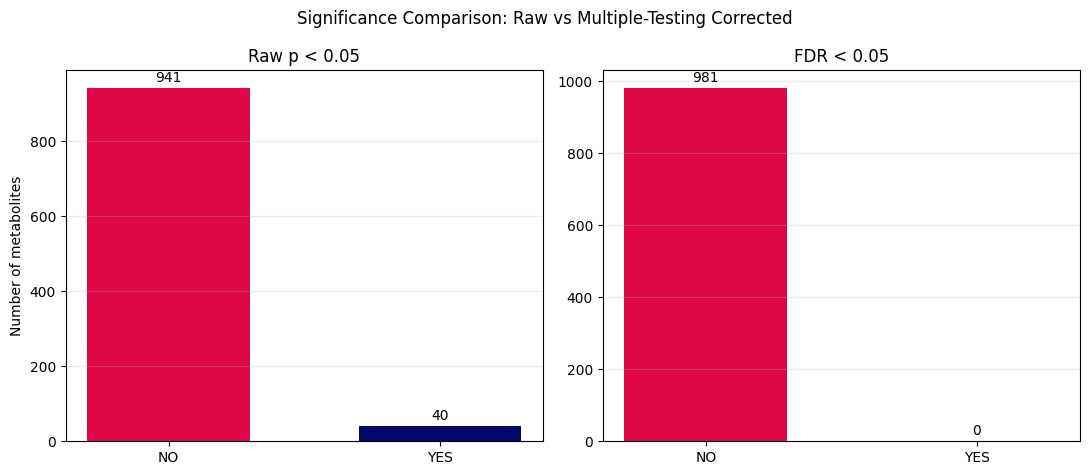

Raw p<0.05: 40/981
FDR<0.05: 0/981


In [31]:
# Side-by-side significance comparison: Raw p<0.05 vs FDR<0.05
import matplotlib.pyplot as plt

alpha = 0.05
cmp_df = results_df[["p_value_raw", "p_value_corrected"]].dropna().copy()

n_total_cmp = len(cmp_df)
raw_yes = int((cmp_df["p_value_raw"] < alpha).sum())
raw_no = n_total_cmp - raw_yes
fdr_yes = int((cmp_df["p_value_corrected"] < alpha).sum())
fdr_no = n_total_cmp - fdr_yes

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# Panel 1: Raw p-value threshold
bars1 = axes[0].bar(["NO", "YES"], [raw_no, raw_yes], color=["#de0848", "#04066c"], width=0.6)
axes[0].set_title("Raw p < 0.05")
axes[0].set_ylabel("Number of metabolites")
axes[0].grid(axis="y", alpha=0.25)
for b in bars1:
    axes[0].text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + max(1, n_total_cmp * 0.01),
        f"{int(b.get_height())}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# Panel 2: FDR threshold
bars2 = axes[1].bar(["NO", "YES"], [fdr_no, fdr_yes], color=["#de0848", "#a018d2"], width=0.6)
axes[1].set_title("FDR < 0.05")
axes[1].grid(axis="y", alpha=0.25)
for b in bars2:
    axes[1].text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + max(1, n_total_cmp * 0.01),
        f"{int(b.get_height())}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

fig.suptitle("Significance Comparison: Raw vs Multiple-Testing Corrected", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Raw p<0.05: {raw_yes}/{n_total_cmp}")
print(f"FDR<0.05: {fdr_yes}/{n_total_cmp}")

In [65]:
# Display 40 significant metabolites with raw p < 0.05
metabolites_p05 = results_df[results_df['p_value_raw'] < 0.05][['Metabolite', 'p_value_raw', 'p_value_corrected', 'Log_Fold_Change', 'Mean_GDM', 'Mean_Non_GDM']].reset_index(drop=True)

print(f"\n{'='*100}")
print(f"SIGNIFICANT METABOLITES (Raw p < 0.05): {len(metabolites_p05)} metabolites")
print(f"{'='*100}\n")

for idx, row in metabolites_p05.iterrows():
    print(f"{idx+1:2d}. {row['Metabolite']:>10s}  |  Raw p: {row['p_value_raw']:.6f}  |  "
          f"FDR: {row['p_value_corrected']:.4f}  |  "
          f"Log FC: {row['Log_Fold_Change']:>7.4f}  |  "
          f"Mean GDM: {row['Mean_GDM']:.4f}  |  Mean Non-GDM: {row['Mean_Non_GDM']:.4f}")

# Also save to CSV
p05_csv_path = os.path.join(os.path.dirname(os.path.dirname(os.path.dirname(OUTPUTS_DIR))), 
                             'outputs/ml_modeling/R_outputs/CSV_files/metabolites_raw_p_lt_0_05.csv')
metabolites_p05.to_csv(p05_csv_path, index=False)
print(f"\n✓ Saved to: {p05_csv_path}")


SIGNIFICANT METABOLITES (Raw p < 0.05): 40 metabolites

 1.     612027  |  Raw p: 0.000836  |  FDR: 0.8198  |  Log FC:  0.0137  |  Mean GDM: 1.0086  |  Mean Non-GDM: 0.9950
 2.     624012  |  Raw p: 0.003435  |  FDR: 0.9514  |  Log FC:  0.0289  |  Mean GDM: 1.0209  |  Mean Non-GDM: 0.9921
 3.     801073  |  Raw p: 0.005975  |  FDR: 0.9514  |  Log FC: -0.0274  |  Mean GDM: 0.9317  |  Mean Non-GDM: 0.9591
 4.     111007  |  Raw p: 0.007513  |  FDR: 0.9514  |  Log FC:  0.0545  |  Mean GDM: 1.0275  |  Mean Non-GDM: 0.9730
 5.     675013  |  Raw p: 0.008627  |  FDR: 0.9514  |  Log FC:  0.0119  |  Mean GDM: 1.0077  |  Mean Non-GDM: 0.9958
 6.     313007  |  Raw p: 0.011026  |  FDR: 0.9514  |  Log FC:  0.0395  |  Mean GDM: 1.0150  |  Mean Non-GDM: 0.9755
 7.     616011  |  Raw p: 0.011318  |  FDR: 0.9514  |  Log FC: -0.0501  |  Mean GDM: 0.9739  |  Mean Non-GDM: 1.0240
 8.     675028  |  Raw p: 0.011712  |  FDR: 0.9514  |  Log FC:  0.0085  |  Mean GDM: 1.0057  |  Mean Non-GDM: 0.9973
 9.    

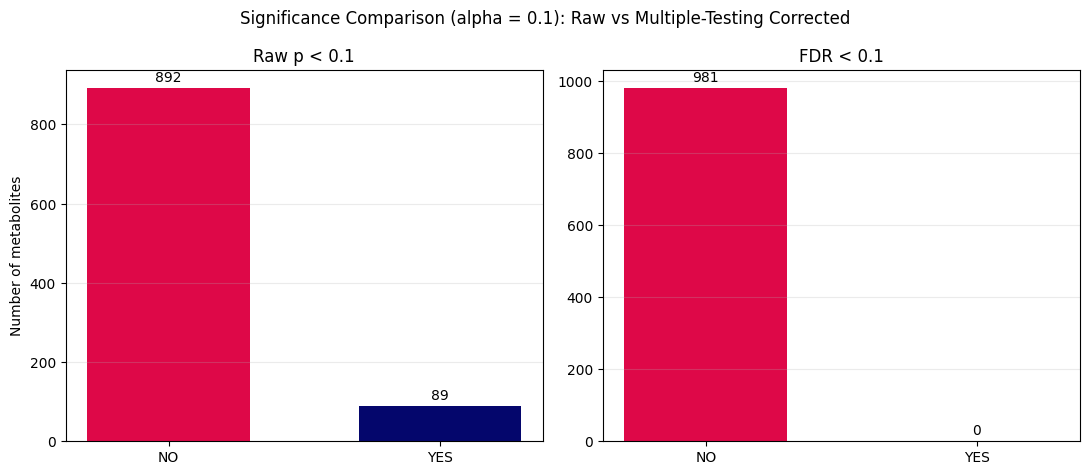

Raw p<0.1: 89/981
FDR<0.1: 0/981


In [34]:
# Side-by-side significance comparison: Raw p<0.1 vs FDR<0.1
import matplotlib.pyplot as plt

alpha = 0.1
cmp_df = results_df[["p_value_raw", "p_value_corrected"]].dropna().copy()

n_total_cmp = len(cmp_df)
raw_yes = int((cmp_df["p_value_raw"] < alpha).sum())
raw_no = n_total_cmp - raw_yes
fdr_yes = int((cmp_df["p_value_corrected"] < alpha).sum())
fdr_no = n_total_cmp - fdr_yes

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# Panel 1: Raw p-value threshold
bars1 = axes[0].bar(["NO", "YES"], [raw_no, raw_yes], color=["#de0848", "#04066c"], width=0.6)
axes[0].set_title("Raw p < 0.1")
axes[0].set_ylabel("Number of metabolites")
axes[0].grid(axis="y", alpha=0.25)
for b in bars1:
    axes[0].text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + max(1, n_total_cmp * 0.01),
        f"{int(b.get_height())}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# Panel 2: FDR threshold
bars2 = axes[1].bar(["NO", "YES"], [fdr_no, fdr_yes], color=["#de0848", "#a018d2"], width=0.6)
axes[1].set_title("FDR < 0.1")
axes[1].grid(axis="y", alpha=0.25)
for b in bars2:
    axes[1].text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + max(1, n_total_cmp * 0.01),
        f"{int(b.get_height())}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

fig.suptitle("Significance Comparison (alpha = 0.1): Raw vs Multiple-Testing Corrected", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Raw p<0.1: {raw_yes}/{n_total_cmp}")
print(f"FDR<0.1: {fdr_yes}/{n_total_cmp}")

In [68]:
# Display significant metabolites with raw p < 0.1
metabolites_p10 = results_df[results_df['p_value_raw'] < 0.1][['Metabolite', 'p_value_raw', 'p_value_corrected', 'Log_Fold_Change', 'Mean_GDM', 'Mean_Non_GDM']].reset_index(drop=True)

print(f"\n{'='*100}")
print(f"SIGNIFICANT METABOLITES (Raw p < 0.1): {len(metabolites_p10)} metabolites")
print(f"{'='*100}\n")

for idx, row in metabolites_p10.iterrows():
    print(f"{idx+1:2d}. {row['Metabolite']:>10s}  |  Raw p: {row['p_value_raw']:.6f}  |  "
          f"FDR: {row['p_value_corrected']:.4f}  |  "
          f"Log FC: {row['Log_Fold_Change']:>7.4f}  |  "
          f"Mean GDM: {row['Mean_GDM']:.4f}  |  Mean Non-GDM: {row['Mean_Non_GDM']:.4f}")

# Also save to CSV
p10_csv_path = os.path.join(
    os.path.dirname(os.path.dirname(os.path.dirname(OUTPUTS_DIR))),
    'outputs/ml_modeling/R_outputs/CSV_files/metabolites_raw_p_lt_0_1_detailed.csv'
)
os.makedirs(os.path.dirname(p10_csv_path), exist_ok=True)
metabolites_p10.to_csv(p10_csv_path, index=False)
print(f"\nSaved to: {p10_csv_path}")


SIGNIFICANT METABOLITES (Raw p < 0.1): 89 metabolites

 1.     612027  |  Raw p: 0.000836  |  FDR: 0.8198  |  Log FC:  0.0137  |  Mean GDM: 1.0086  |  Mean Non-GDM: 0.9950
 2.     624012  |  Raw p: 0.003435  |  FDR: 0.9514  |  Log FC:  0.0289  |  Mean GDM: 1.0209  |  Mean Non-GDM: 0.9921
 3.     801073  |  Raw p: 0.005975  |  FDR: 0.9514  |  Log FC: -0.0274  |  Mean GDM: 0.9317  |  Mean Non-GDM: 0.9591
 4.     111007  |  Raw p: 0.007513  |  FDR: 0.9514  |  Log FC:  0.0545  |  Mean GDM: 1.0275  |  Mean Non-GDM: 0.9730
 5.     675013  |  Raw p: 0.008627  |  FDR: 0.9514  |  Log FC:  0.0119  |  Mean GDM: 1.0077  |  Mean Non-GDM: 0.9958
 6.     313007  |  Raw p: 0.011026  |  FDR: 0.9514  |  Log FC:  0.0395  |  Mean GDM: 1.0150  |  Mean Non-GDM: 0.9755
 7.     616011  |  Raw p: 0.011318  |  FDR: 0.9514  |  Log FC: -0.0501  |  Mean GDM: 0.9739  |  Mean Non-GDM: 1.0240
 8.     675028  |  Raw p: 0.011712  |  FDR: 0.9514  |  Log FC:  0.0085  |  Mean GDM: 1.0057  |  Mean Non-GDM: 0.9973
 9.     

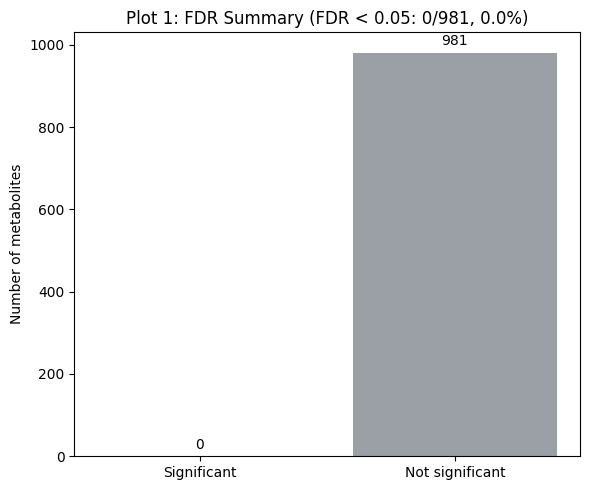

Conclusion: No statistically significant metabolite differences were detected between GDM-positive and non-GDM women at FDR < 0.05.


In [66]:
# Final conclusion plots: Significant difference between GDM-positive and non-GDM women
import numpy as np
import matplotlib.pyplot as plt

if "results_df" not in globals():
    raise NameError("results_df not found. Run Step 17 before this plot.")

plot_df = results_df.copy()
required_cols = {"Log_Fold_Change", "p_value_corrected"}
missing_cols = required_cols - set(plot_df.columns)
if missing_cols:
    raise ValueError(f"results_df is missing required columns: {sorted(missing_cols)}")

plot_df = plot_df.dropna(subset=["Log_Fold_Change", "p_value_corrected"]).copy()
plot_df["neg_log10_fdr"] = -np.log10(np.clip(plot_df["p_value_corrected"].astype(float), 1e-300, 1.0))
plot_df["significant_fdr"] = plot_df["p_value_corrected"].astype(float) < 0.05

sig_n = int(plot_df["significant_fdr"].sum())
non_sig_n = int((~plot_df["significant_fdr"]).sum())
total_n = sig_n + non_sig_n
sig_pct = (100 * sig_n / total_n) if total_n else 0.0



# Plot 1: Significant vs not significant counts
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Significant", "Not significant"], [sig_n, non_sig_n], color=["#d1495b", "#9aa0a6"])
ax.set_ylabel("Number of metabolites")
ax.set_title(f"Plot 1: FDR Summary (FDR < 0.05: {sig_n}/{total_n}, {sig_pct:.1f}%)")
for i, v in enumerate([sig_n, non_sig_n]):
    ax.text(i, v + max(1, total_n * 0.01), str(v), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

if sig_n > 0:
    print(f"Conclusion: Significant metabolite differences are present between GDM-positive and non-GDM women ({sig_n} metabolites at FDR < 0.05).")
else:
    print("Conclusion: No statistically significant metabolite differences were detected between GDM-positive and non-GDM women at FDR < 0.05.")

# Reasons:
# Multiple-testing burden is large (981 simultaneous tests).
# Sample size after cleaning is modest (about 34), limiting power.
# True effects may be small relative to biological variability.


In [27]:
# Export final cleaned modeling inputs for exact Python-to-R parity
export_dir = os.path.join(OUTPUTS_DIR, "ml_modeling", "output_csv", "08_cord_gdm")
os.makedirs(export_dir, exist_ok=True)

cord_clean_export_path = os.path.join(export_dir, "cord_clean_from_python.csv")
cov_clean_export_path = os.path.join(export_dir, "cov_clean_from_python.csv")

cord_clean.to_csv(cord_clean_export_path, index=True, index_label="Sample")
cov_clean.to_csv(cov_clean_export_path, index=True, index_label="Sample")

print(f"Saved cord_clean to: {cord_clean_export_path}")
print(f"Saved cov_clean to: {cov_clean_export_path}")
print(f"cord_clean shape: {cord_clean.shape}")
print(f"cov_clean shape: {cov_clean.shape}")

Saved cord_clean to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/output_csv/08_cord_gdm/cord_clean_from_python.csv
Saved cov_clean to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/output_csv/08_cord_gdm/cov_clean_from_python.csv
cord_clean shape: (38, 981)
cov_clean shape: (38, 6)


In [69]:
# Extract and save just the 89 metabolite names (raw p < 0.1)
metabolites_raw_p_01 = results_df[results_df['p_value_raw'] < 0.1]['Metabolite'].tolist()

# Save as simple text file (one per line)
metabolite_names_path = os.path.join(
    os.path.dirname(os.path.dirname(os.path.dirname(OUTPUTS_DIR))),
    'outputs/ml_modeling/Python_outputs/CSV_files/89_metabolites_raw_p_lt_0_1.txt'
)
os.makedirs(os.path.dirname(metabolite_names_path), exist_ok=True)
with open(metabolite_names_path, 'w') as f:
    for metabolite in metabolites_raw_p_01:
        f.write(f"{metabolite}\n")

print(f"Saved {len(metabolites_raw_p_01)} metabolite names to: {metabolite_names_path}")
print("\nMetabolite names (first 10):")
for i, met in enumerate(metabolites_raw_p_01[:10], 1):
    print(f"  {i}. {met}")

Saved 89 metabolite names to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/outputs/ml_modeling/Python_outputs/CSV_files/89_metabolites_raw_p_lt_0_1.txt

Metabolite names (first 10):
  1. 612027
  2. 624012
  3. 801073
  4. 111007
  5. 675013
  6. 313007
  7. 616011
  8. 675028
  9. 634009
  10. 624003


In [70]:
# Save 89 metabolites as a table in the Python_outputs directory
metabolites_df = results_df[results_df['p_value_raw'] < 0.1][['Metabolite', 'p_value_raw', 'p_value_corrected', 'Log_Fold_Change']].reset_index(drop=True)
metabolites_df.index.name = 'Index'
metabolites_df = metabolites_df.reset_index()

# Save to the Python_outputs CSV directory
python_outputs_csv_path = os.path.join(
    os.path.dirname(os.path.dirname(os.path.dirname(OUTPUTS_DIR))),
    'outputs/ml_modeling/Python_outputs/CSV_files/metabolites_raw_p_lt_0_1.csv'
)
os.makedirs(os.path.dirname(python_outputs_csv_path), exist_ok=True)
metabolites_df.to_csv(python_outputs_csv_path, index=False)

print(f"Saved 89 metabolites table to: {python_outputs_csv_path}")
print(f"\nTable shape: {metabolites_df.shape}")
print("\nFirst 10 rows:")
print(metabolites_df.head(10))

Saved 89 metabolites table to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/outputs/ml_modeling/Python_outputs/CSV_files/metabolites_raw_p_lt_0_1.csv

Table shape: (89, 5)

First 10 rows:
   Index Metabolite  p_value_raw  p_value_corrected  Log_Fold_Change
0      0     612027     0.000836           0.819783         0.013654
1      1     624012     0.003435           0.951433         0.028863
2      2     801073     0.005975           0.951433        -0.027391
3      3     111007     0.007513           0.951433         0.054472
4      4     675013     0.008627           0.951433         0.011914
5      5     313007     0.011026           0.951433         0.039470
6      6     616011     0.011318           0.951433        -0.050072
7      7     675028     0.011712           0.951433         0.008453
8      8     634009     0.011802           0.951433         0.015371
9      9     624003     0.012351           0.95143

In [ ]:
# # Steps 6-13: Main loop across all metabolites (R translation)
# #
# # Expected inputs already loaded in the R session:
# # - cord_clean: data.frame with rows = samples, columns = metabolites
# # - cov_clean:  data.frame with rows = samples, columns = covariates (including GDM)

# if (!exists("cord_clean") || !exists("cov_clean")) {
#   stop("Required objects not found: 'cord_clean' and 'cov_clean' must exist before running this script.")
# }

# metabolite_annotations <- colnames(cord_clean)

# p_store <- numeric(0)
# m_GDM_store <- numeric(0)
# m_non_GDM_store <- numeric(0)
# log_fc_store <- numeric(0)
# raw_fc_store <- numeric(0)

# cat(sprintf("Starting loop over %d metabolites...\n", length(metabolite_annotations)))
# cat("This will apply Steps 6-13 to each metabolite.\n\n")

# for (i in seq_along(metabolite_annotations)) {
#   metabolite_name <- metabolite_annotations[i]

#   # 1) Extract metabolite i and combine with covariates
#   model_data <- data.frame(
#     metabolite = cord_clean[[metabolite_name]],
#     cov_clean,
#     check.names = FALSE
#   )
#   model_data <- model_data[stats::complete.cases(model_data), , drop = FALSE]

#   if (nrow(model_data) == 0 || length(unique(model_data$GDM)) < 2) {
#     p_store <- c(p_store, NA_real_)
#     m_GDM_store <- c(m_GDM_store, NA_real_)
#     m_non_GDM_store <- c(m_non_GDM_store, NA_real_)
#     log_fc_store <- c(log_fc_store, NA_real_)
#     raw_fc_store <- c(raw_fc_store, NA_real_)
#   } else {
#     # 2) Fit lm(metabolite[i] ~ GDM + covariates)
#     rhs_terms <- setdiff(colnames(cov_clean), "GDM")
#     formula_str <- if (length(rhs_terms) > 0) {
#       paste("metabolite ~ GDM +", paste(rhs_terms, collapse = " + "))
#     } else {
#       "metabolite ~ GDM"
#     }
#     fit <- stats::lm(stats::as.formula(formula_str), data = model_data)

#     # 3) Extract p-value for GDM
#     coef_table <- summary(fit)$coefficients
#     gdm_rows <- grep("^GDM", rownames(coef_table))
#     gdm_pval <- if (length(gdm_rows) >= 1) coef_table[gdm_rows[1], "Pr(>|t|)"] else NA_real_

#     # 4-5) Means by group
#     gdm_char <- as.character(model_data$GDM)
#     gdm_vals <- model_data$metabolite[gdm_char %in% c("1", "1.0")]
#     non_gdm_vals <- model_data$metabolite[gdm_char %in% c("0", "0.0")]

#     m_gdm <- if (length(gdm_vals) > 0) mean(gdm_vals, na.rm = TRUE) else NA_real_
#     m_non_gdm <- if (length(non_gdm_vals) > 0) mean(non_gdm_vals, na.rm = TRUE) else NA_real_

#     # 6) Log fold change
#     log_fc <- if (!is.na(m_gdm) && !is.na(m_non_gdm)) m_gdm - m_non_gdm else NA_real_

#     # 7) Convert to raw fold change (2^log_fc)
#     raw_fc <- if (!is.na(log_fc)) 2^log_fc else NA_real_

#     # 8) Store values in vectors
#     p_store <- c(p_store, gdm_pval)
#     m_GDM_store <- c(m_GDM_store, m_gdm)
#     m_non_GDM_store <- c(m_non_GDM_store, m_non_gdm)
#     log_fc_store <- c(log_fc_store, log_fc)
#     raw_fc_store <- c(raw_fc_store, raw_fc)
#   }

#   if (i %% 100 == 0) {
#     cat(sprintf("  Processed %d metabolites...\n", i))
#   }
# }

# cat(sprintf("\nCompleted loop. Processed %d metabolites.\n", length(metabolite_annotations)))
# cat(sprintf("  p-values stored: %d\n", length(p_store)))
# cat(sprintf("  GDM means stored: %d\n", length(m_GDM_store)))
# cat(sprintf("  Non-GDM means stored: %d\n", length(m_non_GDM_store)))
# cat(sprintf("  Fold changes stored: %d\n", length(raw_fc_store)))

# # ## Step 14: Exit Loop and Prepare for Multiple Testing Correction
# #
# # Convert stored vectors to arrays for further processing:
# # - p_store: raw p-values
# # - m_GDM_store: mean metabolite levels in GDM=1 group
# # - m_non_GDM_store: mean metabolite levels in GDM=0 group
# # - log_fc_store: log fold changes
# # - raw_fc_store: raw fold changes

# # Step 14: Convert to vectors for further processing
# p_array <- as.numeric(p_store)
# m_gdm_array <- as.numeric(m_GDM_store)
# m_non_gdm_array <- as.numeric(m_non_GDM_store)
# log_fc_array <- as.numeric(log_fc_store)
# raw_fc_array <- as.numeric(raw_fc_store)

# cat("Results vectors prepared:\n")
# cat(sprintf("  p-values: %d\n", length(p_array)))
# cat(sprintf("  GDM means: %d\n", length(m_gdm_array)))
# cat(sprintf("  Non-GDM means: %d\n", length(m_non_gdm_array)))
# cat(sprintf("  Log fold changes: %d\n", length(log_fc_array)))
# cat(sprintf("  Raw fold changes: %d\n", length(raw_fc_array)))

# cat("\nP-value summary:\n")
# if (all(is.na(p_array))) {
#   cat("  Min: NA\n")
#   cat("  Max: NA\n")
#   cat("  Mean: NA\n")
#   cat("  Median: NA\n")
# } else {
#   cat(sprintf("  Min: %s\n", min(p_array, na.rm = TRUE)))
#   cat(sprintf("  Max: %s\n", max(p_array, na.rm = TRUE)))
#   cat(sprintf("  Mean: %s\n", mean(p_array, na.rm = TRUE)))
#   cat(sprintf("  Median: %s\n", stats::median(p_array, na.rm = TRUE)))
# }

# # ## Step 15: Calculate Adjusted P-values Using Benjamini-Hochberg
# #
# # Apply Benjamini-Hochberg (FDR) correction to the p-value vector to control
# # false discovery rate across all metabolite tests.

# # Step 15: Calculate adjusted p-values using Benjamini-Hochberg
# valid_p_mask <- !is.na(p_array)
# pvals_adj_bh <- rep(NA_real_, length(p_array))

# if (any(valid_p_mask)) {
#   pvals_adj_bh[valid_p_mask] <- stats::p.adjust(p_array[valid_p_mask], method = "BH")
# }

# reject_bh <- !is.na(pvals_adj_bh) & (pvals_adj_bh < 0.05)

# cat("Benjamini-Hochberg Correction Results:\n")
# cat(sprintf("  Number of significant metabolites (FDR < 0.05): %d\n", sum(reject_bh, na.rm = TRUE)))

# if (all(is.na(pvals_adj_bh))) {
#   cat("  Min adjusted p-value: NA\n")
#   cat("  Max adjusted p-value: NA\n")
#   cat("  Mean adjusted p-value: NA\n")
#   cat("  Median adjusted p-value: NA\n")
# } else {
#   cat(sprintf("  Min adjusted p-value: %s\n", min(pvals_adj_bh, na.rm = TRUE)))
#   cat(sprintf("  Max adjusted p-value: %s\n", max(pvals_adj_bh, na.rm = TRUE)))
#   cat(sprintf("  Mean adjusted p-value: %s\n", mean(pvals_adj_bh, na.rm = TRUE)))
#   cat(sprintf("  Median adjusted p-value: %s\n", stats::median(pvals_adj_bh, na.rm = TRUE)))
# }

# # ## Step 16: Calculate Q-values
# #
# # Q-values provide another measure of statistical significance considering the
# # proportion of false discoveries.
# # This uses the qvalue method (Storey's approach) to estimate the FDR at each
# # p-value threshold.

# # Step 16: Calculate q-values
# q_vals <- rep(NA_real_, length(p_array))
# qvalue_available <- requireNamespace("qvalue", quietly = TRUE)

# if (qvalue_available && any(valid_p_mask)) {
#   q_obj <- qvalue::qvalue(p = p_array[valid_p_mask])
#   q_vals[valid_p_mask] <- as.numeric(q_obj$qvalues)
#   cat("Q-values calculated using qvalue package\n")
# } else {
#   cat("qvalue package not available, using Benjamini-Hochberg adjusted p-values as approximation\n")
#   q_vals <- pvals_adj_bh
# }

# cat("\nQ-value Summary:\n")
# if (all(is.na(q_vals))) {
#   cat("  Min: NA\n")
#   cat("  Max: NA\n")
#   cat("  Mean: NA\n")
#   cat("  Median: NA\n")
# } else {
#   cat(sprintf("  Min: %s\n", min(q_vals, na.rm = TRUE)))
#   cat(sprintf("  Max: %s\n", max(q_vals, na.rm = TRUE)))
#   cat(sprintf("  Mean: %s\n", mean(q_vals, na.rm = TRUE)))
#   cat(sprintf("  Median: %s\n", stats::median(q_vals, na.rm = TRUE)))
# }

# # ## Step 17: Create Results Table
# #
# # Combine all results into a comprehensive table containing:
# # 1. Metabolite Annotation - metabolite names/IDs
# # 2. p-value (raw) - unadjusted p-values from linear models
# # 3. p-value (corrected) - Benjamini-Hochberg adjusted p-values
# # 4. q-value - Storey's q-values
# # 5. Mean GDM - mean metabolite level in GDM positive women
# # 6. Mean Non-GDM - mean metabolite level in non-GDM women
# # 7. Log Fold Change - log-scale difference between groups
# # 8. Raw Fold Change - back-transformed fold change (2^log_fc)

# # Step 17: Create comprehensive results table

# # Use metabolite_names if available; otherwise use metabolite_annotations from the main loop
# if (exists("metabolite_names")) {
#   metabolite_names_local <- metabolite_names
# } else {
#   metabolite_names_local <- metabolite_annotations
# }

# # Get metabolite annotations if available
# anno_df <- NULL
# if (exists("CORD_ANNO") && !is.null(CORD_ANNO) && !is.na(CORD_ANNO) && file.exists(CORD_ANNO)) {
#   anno_df <- utils::read.csv(CORD_ANNO, row.names = 1, check.names = FALSE)
# }

# # Create results dataframe
# results_df <- data.frame(
#   Metabolite = metabolite_names_local,
#   p_value_raw = p_array,
#   p_value_corrected = pvals_adj_bh,
#   q_value = q_vals,
#   Mean_GDM = m_gdm_array,
#   Mean_Non_GDM = m_non_gdm_array,
#   Log_Fold_Change = log_fc_array,
#   Raw_Fold_Change = raw_fc_array,
#   check.names = FALSE,
#   stringsAsFactors = FALSE
# )

# # Add metabolite annotation if available
# if (!is.null(anno_df)) {
#   anno_expanded <- anno_df[match(metabolite_names_local, rownames(anno_df)), , drop = FALSE]
#   rownames(anno_expanded) <- NULL
#   results_df <- cbind(results_df, anno_expanded)
# }

# # Sort by p-value (most significant first)
# results_df <- results_df[order(results_df$p_value_raw, na.last = TRUE), , drop = FALSE]
# rownames(results_df) <- NULL

# cat("Results Table Summary:\n")
# cat(sprintf("  Total metabolites: %d\n", nrow(results_df)))
# cat("\nFirst 10 rows (sorted by p-value):\n")
# print(utils::head(results_df, 10))




# # Save Step 17 results to CSV
# save_path <- file.path("outputs", "ml_modeling", "output_csv", "08_cord_gdm", "R_Output.csv")
# dir.create(dirname(save_path), recursive = TRUE, showWarnings = FALSE)

# utils::write.csv(results_df, save_path, row.names = FALSE)
# cat(sprintf("\nSaved results to: %s\n", save_path))
# cat(sprintf("Rows: %d, Columns: %d\n", nrow(results_df), ncol(results_df)))





# # ## Step 18: Plot Histograms in Separate Figures
# #
# # Create and save 4 separate histograms for:
# # 1) Raw p-values
# # 2) BH-adjusted p-values
# # 3) Log fold change
# # 4) Raw fold change

# img_dir <- file.path("outputs", "ml_modeling", "output_images", "08_cord_gdm_in_R")
# dir.create(img_dir, recursive = TRUE, showWarnings = FALSE)

# save_histogram <- function(x, plot_title, x_label, out_file, color) {
#   x_non_na <- x[!is.na(x)]
#   if (length(x_non_na) == 0) {
#     cat(sprintf("Skipping %s (all values are NA)\n", out_file))
#     return(invisible(NULL))
#   }

#   grDevices::png(filename = out_file, width = 900, height = 650, res = 120)
#   hist(
#     x_non_na,
#     breaks = 30,
#     col = color,
#     border = "white",
#     main = plot_title,
#     xlab = x_label
#   )
#   grDevices::dev.off()
#   cat(sprintf("Saved histogram: %s\n", out_file))
# }

# save_histogram(
#   x = results_df$p_value_raw,
#   plot_title = "Histogram: Raw p-values",
#   x_label = "p_value_raw",
#   out_file = file.path(img_dir, "hist_raw_p_values.png"),
#   color = "#4C78A8"
# )

# save_histogram(
#   x = results_df$p_value_corrected,
#   plot_title = "Histogram: BH-adjusted p-values",
#   x_label = "p_value_corrected",
#   out_file = file.path(img_dir, "hist_bh_adjusted_p_values.png"),
#   color = "#F58518"
# )

# save_histogram(
#   x = results_df$Log_Fold_Change,
#   plot_title = "Histogram: Log Fold Change",
#   x_label = "Log_Fold_Change",
#   out_file = file.path(img_dir, "hist_log_fold_change.png"),
#   color = "#54A24B"
# )

# save_histogram(
#   x = results_df$Raw_Fold_Change,
#   plot_title = "Histogram: Raw Fold Change",
#   x_label = "Raw_Fold_Change",
#   out_file = file.path(img_dir, "hist_raw_fold_change.png"),
#   color = "#E45756"
# )
